In [1]:
#ENV: HI
# Import data processing modules
import pandas as pd # used throughout the code
import numpy as np # used throughout the code

# Import visualization modules
import matplotlib.pyplot as plt # used for simple bar charts and as basis for plotly and seaborn library
from textwrap import fill # used for scatterplot in data analysis section after disaggregation

# Display options
pd.options.display.float_format = '{:,.2f}'.format #limits printed decimal points to two


geo = False

if geo == True: #ENV: geo_env
    import geopandas as gpd
    
    import matplotlib.colors as colors
    from matplotlib import colormaps
    from matplotlib.gridspec import GridSpec
    from matplotlib import rcParams

    #%% Global plotting settings
    #rcParams['font.family'] = 'Bitstream Vera Sans'
    rcParams['font.size'] = 10

    #shapefiles
    nuts = gpd.read_file('data/input_detailing_NUTS/NUTS_RG_20M_2024_3035.gpkg') #need to match the coordinate systems between gdf and nuts
    nuts = nuts.loc[nuts['NUTS_ID'].str.len() == 5] #only NUTS3 level
    nuts = nuts[['NUTS_ID', 'geometry']]
else:
    import seaborn as sns
    import plotly.express as px # used for all stacked bar charts
    import plotly.graph_objects as go # used for marimekko plot and for annotating stacked bar charts

## Sanity check: all regions consistent?
- household size
- floor area per capita
- population size
- population growth

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_21358/1406198201.py:13: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df = df.groupby(by=['region_nuts', 'year'], axis=0).mean(numeric_only=True).reset_index()


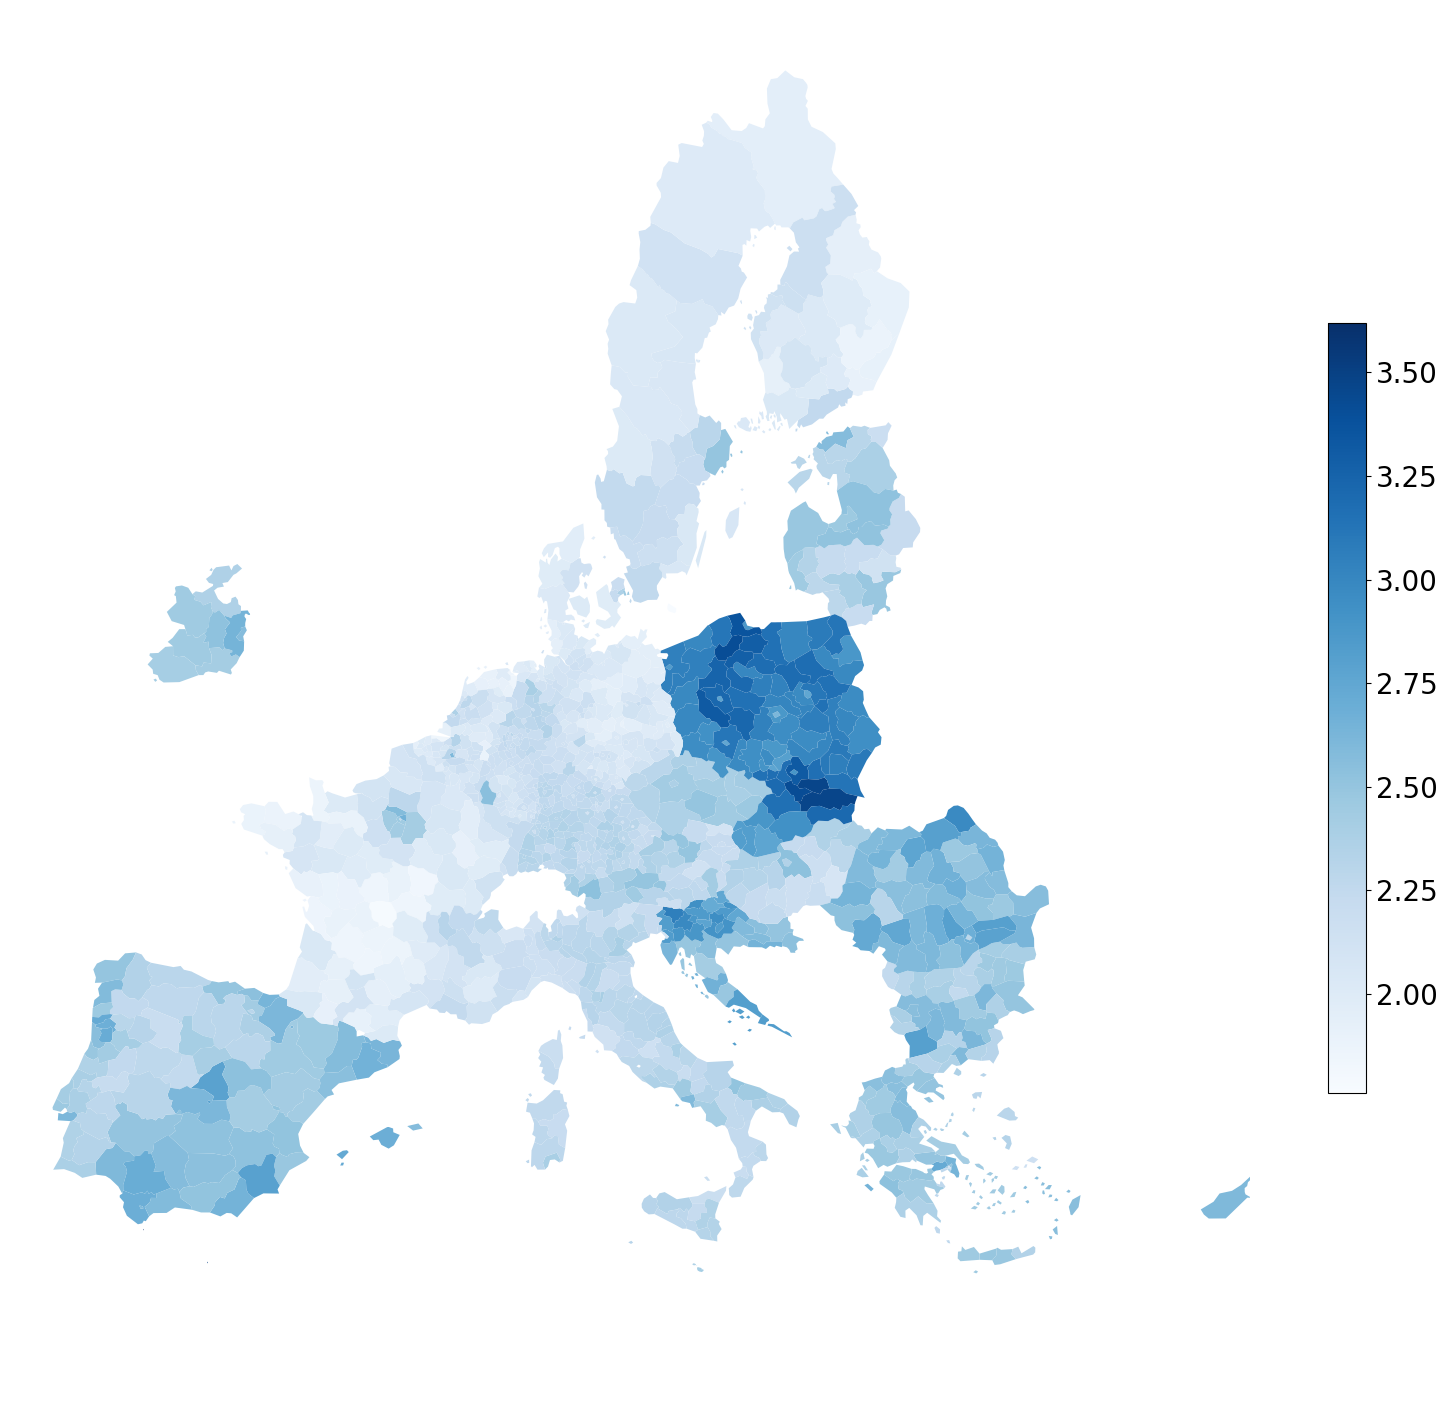

In [2]:
#data import
file = 'hh_size_rev_nuts.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)

if geo==False:
    for i in df.columns.drop(['region_nuts', 'value']):
        hue=i
        sns.histplot(data=df, x='value', hue=hue)
        plt.savefig('plots/'+file[0:8]+hue+'.png')
        plt.show()
        plt.close()
else:
    df = df.groupby(by=['region_nuts', 'year'], axis=0).mean(numeric_only=True).reset_index()

    #merging shape with data
    df['NUTS_ID'] = df.region_nuts.str[10:]
    df_gdf = pd.merge(df, nuts, on='NUTS_ID')

    year = 2050
    gdf = gpd.GeoDataFrame(df_gdf[df_gdf['year']==year])
    col = 'value'
    ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
                #cmap='RdBu_r', 
                cmap='Blues', #inferno_r
                #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
                #norm=custom_norm, 
                edgecolor=None,
                missing_kwds={'color': 'lightgrey'},
                legend_kwds={"shrink":.5},)
    ax.figure.axes[1].tick_params(labelsize=20)
    ax.set_xlim(0.25e7, 0.65e7)
    ax.set_ylim(1e6, 5.5e6)
    ax.set_axis_off()
    plt.savefig('plots/map_'+file[0:8]+'_'+str(year)+'.png')
    plt.show()

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_21358/2520756445.py:12: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df = df.groupby(by=['region_nuts', 'year'], axis=0).mean(numeric_only=True).reset_index()


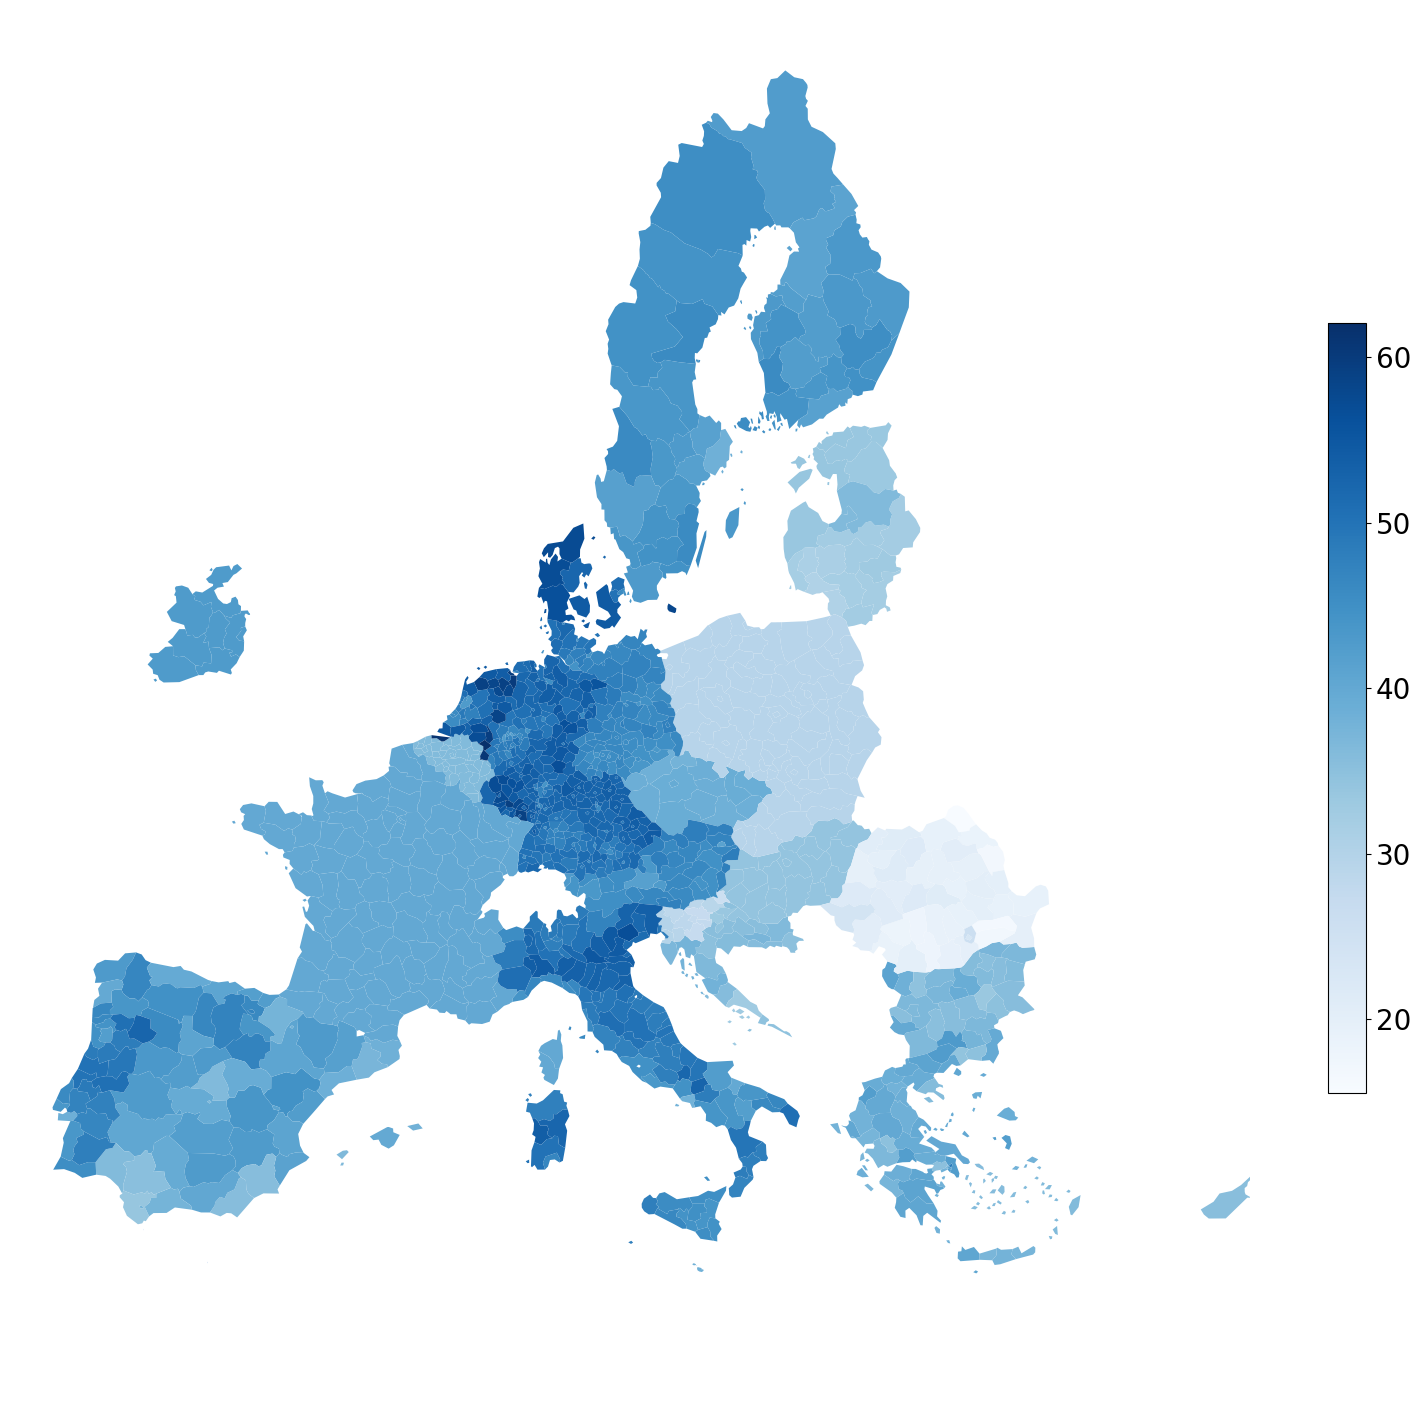

In [6]:
#data import
file = 'floor_resid_ssp2_rev_nuts.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
if geo==False:
    for i in df.columns.drop(['region_nuts', 'value']):
        hue=i
        sns.histplot(data=df, x='value', hue=hue)
        plt.savefig('plots/'+file[0:8]+hue+'.png')
        plt.show()
        plt.close()
else:
    df = df.groupby(by=['region_nuts', 'year'], axis=0).mean(numeric_only=True).reset_index()

    #merging shape with data
    df['NUTS_ID'] = df.region_nuts.str[10:]
    df_gdf = pd.merge(df, nuts, on='NUTS_ID')

    year = 2020
    gdf = gpd.GeoDataFrame(df_gdf[df_gdf['year']==year])
    col = 'value'
    ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
                #cmap='RdBu_r', 
                cmap='Blues', #inferno_r
                #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
                #norm=custom_norm, 
                edgecolor=None,
                missing_kwds={'color': 'lightgrey'},
                legend_kwds={"shrink":.5},)
    ax.figure.axes[1].tick_params(labelsize=20)
    ax.set_xlim(0.25e7, 0.65e7)
    ax.set_ylim(1e6, 5.5e6)
    ax.set_axis_off()
    plt.savefig('plots/map_'+file[0:8]+'_'+str(year)+'.png', bbox_inches='tight')
    plt.show()

#floor area per capita/dwelling data only available for some countries for EU, therefore countries like France show uniform floor area estimates

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_21358/1330431854.py:12: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df = df.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).mul(1e6).reset_index()


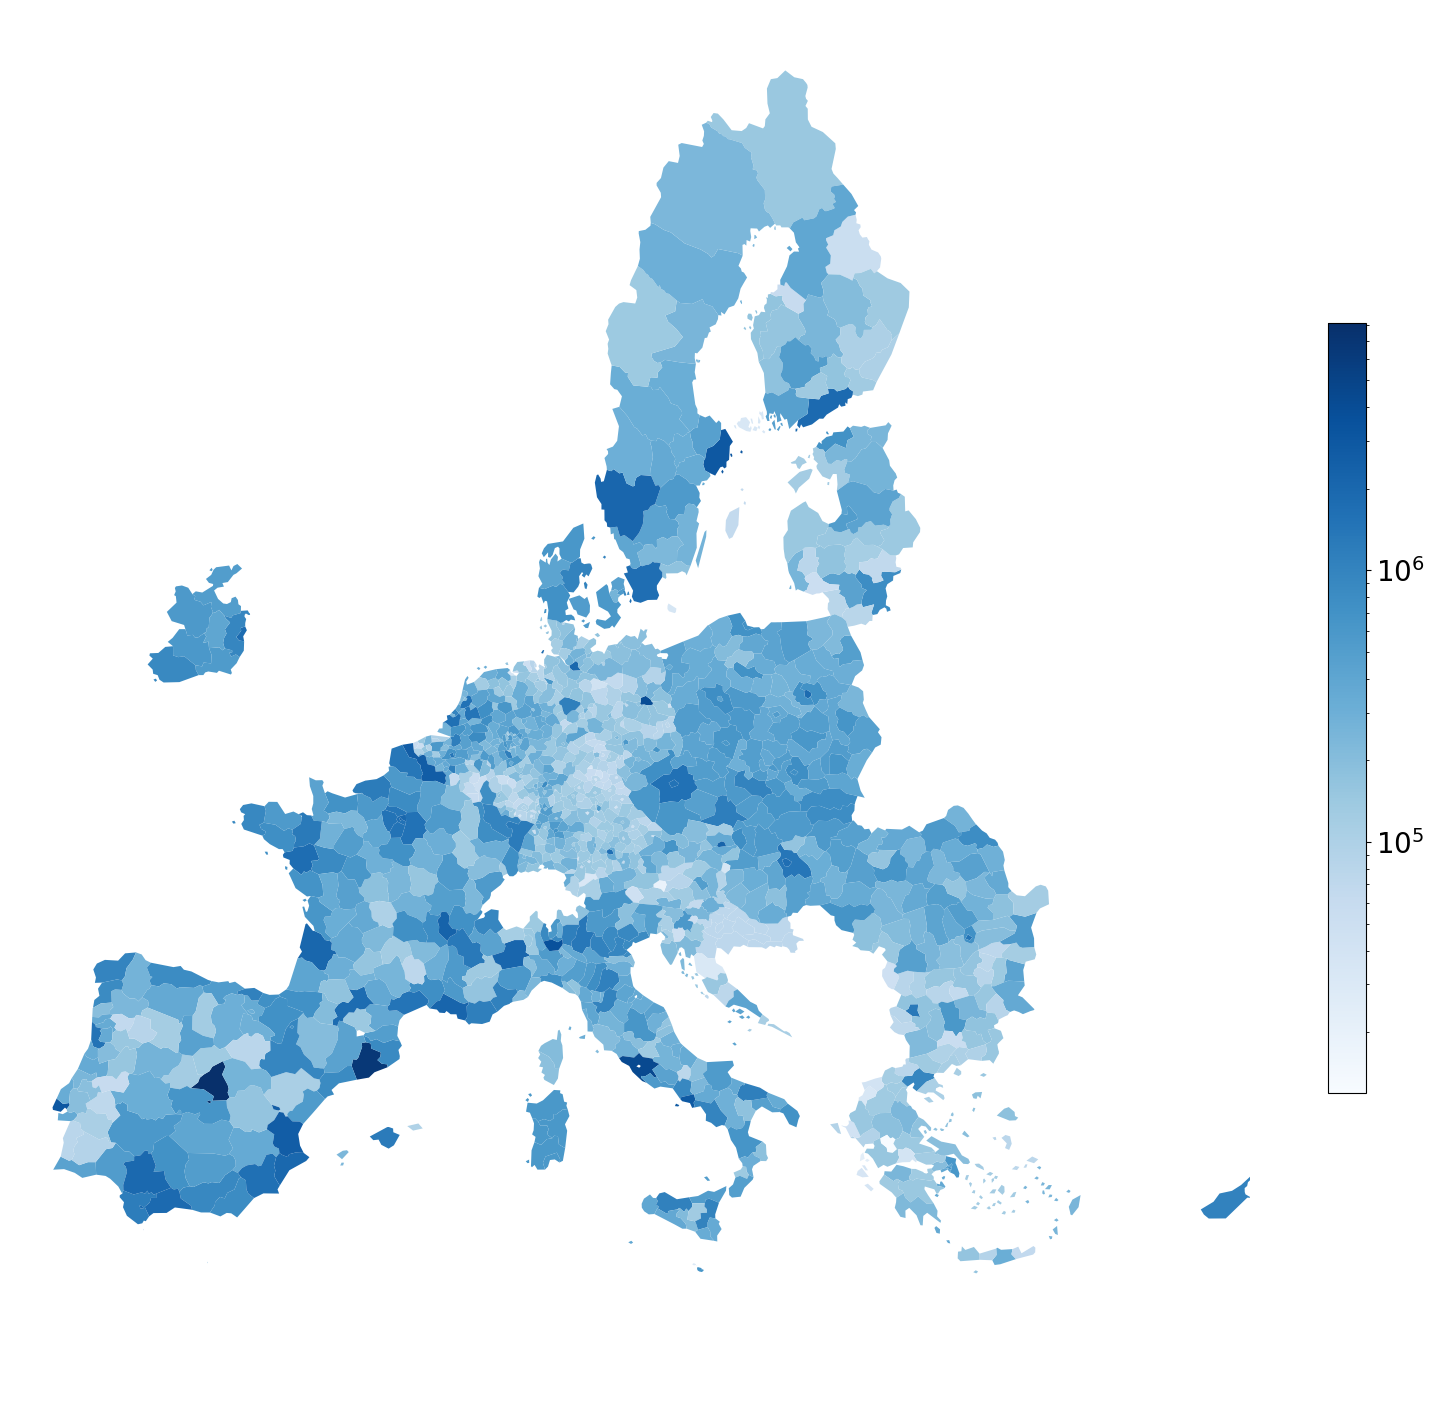

In [10]:
#data import
file = 'pop_clim_rev_SSP2_nuts.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
if geo==False:
    for i in df.columns.drop(['region_nuts', 'value']):
        hue=i
        sns.histplot(data=df, x='value', hue=hue)
        plt.savefig('plots/'+file[0:8]+hue+'.png')
        plt.show()
        plt.close()
else:
    df = df.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).mul(1e6).reset_index()

    #merging shape with data
    df['NUTS_ID'] = df.region_nuts.str[10:]
    df_gdf = pd.merge(df, nuts, on='NUTS_ID')

    year = 2050
    gdf = gpd.GeoDataFrame(df_gdf[df_gdf['year']==year])
    col = 'value'
    ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
                #cmap='RdBu_r', 
                cmap='Blues', #inferno_r
                norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
                #norm=custom_norm, 
                edgecolor=None,
                missing_kwds={'color': 'lightgrey'},
                legend_kwds={"shrink":.5},)
    ax.figure.axes[1].tick_params(labelsize=20)
    ax.set_xlim(0.25e7, 0.65e7)
    ax.set_ylim(1e6, 5.5e6)
    ax.set_axis_off()
    plt.savefig('plots/map_'+file[0:8]+'_'+str(year)+'.png', bbox_inches='tight')
    plt.show()

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_21358/1660134280.py:7: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df = df.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).mul(1e6)


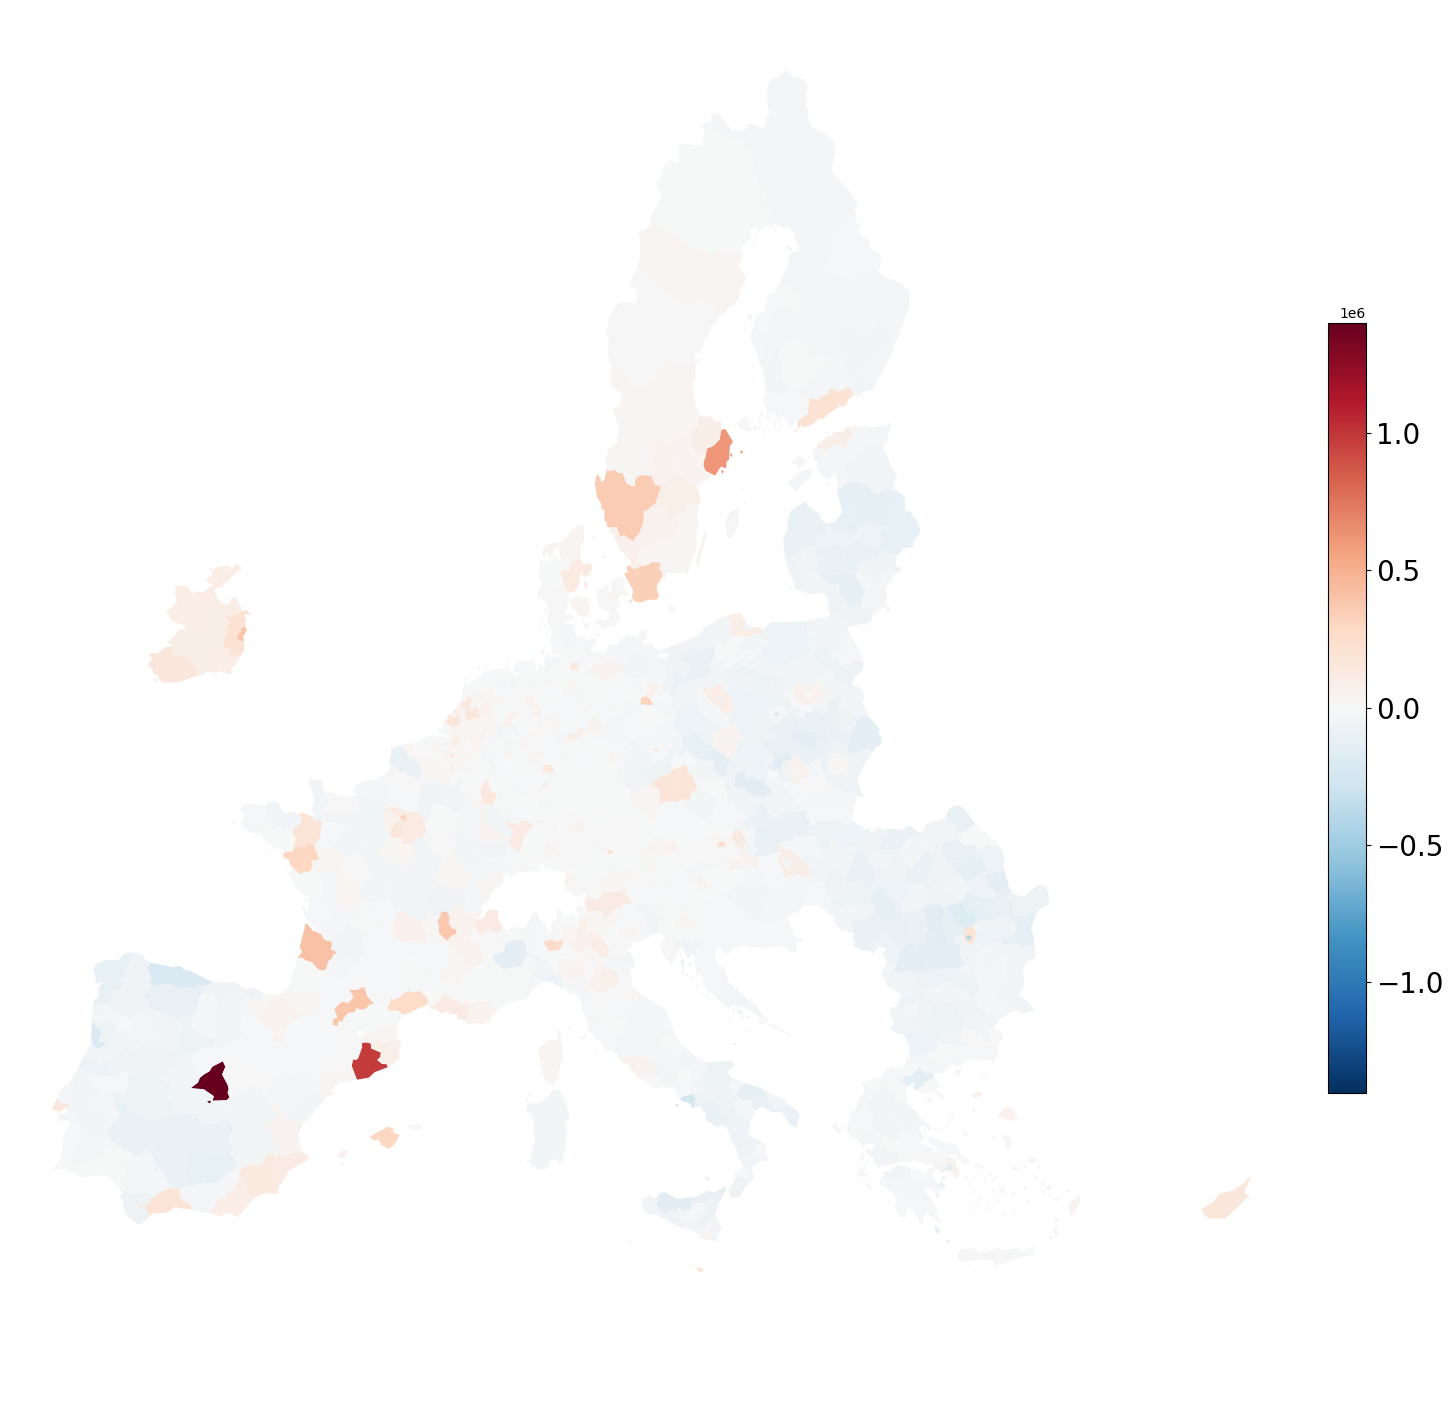

In [26]:
#data import
file = 'pop_clim_rev_SSP2_nuts.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
if geo==False:
    None
else:
    df = df.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).mul(1e6)
    df = df.unstack('year').droplevel(0, axis=1)
    df['pop_change'] = df[2050] - df[2020]
    df = df.loc[:,'pop_change'].reset_index()

    #merging shape with data
    df['NUTS_ID'] = df.region_nuts.str[10:]
    df_gdf = pd.merge(df, nuts, on='NUTS_ID')

    gdf = gpd.GeoDataFrame(df_gdf)
    col = 'pop_change'
    ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
                cmap='RdBu_r', 
                #cmap='Blues', #inferno_r
                #norm=colors.LogNorm(vmin=-1.5, vmax=1.5),
                norm=colors.CenteredNorm(), 
                edgecolor=None,
                missing_kwds={'color': 'lightgrey'},
                legend_kwds={"shrink":.5},)
    ax.figure.axes[1].tick_params(labelsize=20)
    ax.set_xlim(0.25e7, 0.65e7)
    ax.set_ylim(1e6, 5.5e6)
    ax.set_axis_off()
    plt.savefig('plots/map_'+file[0:8]+'_'+'change20202050'+'.png', bbox_inches='tight')
    plt.show()

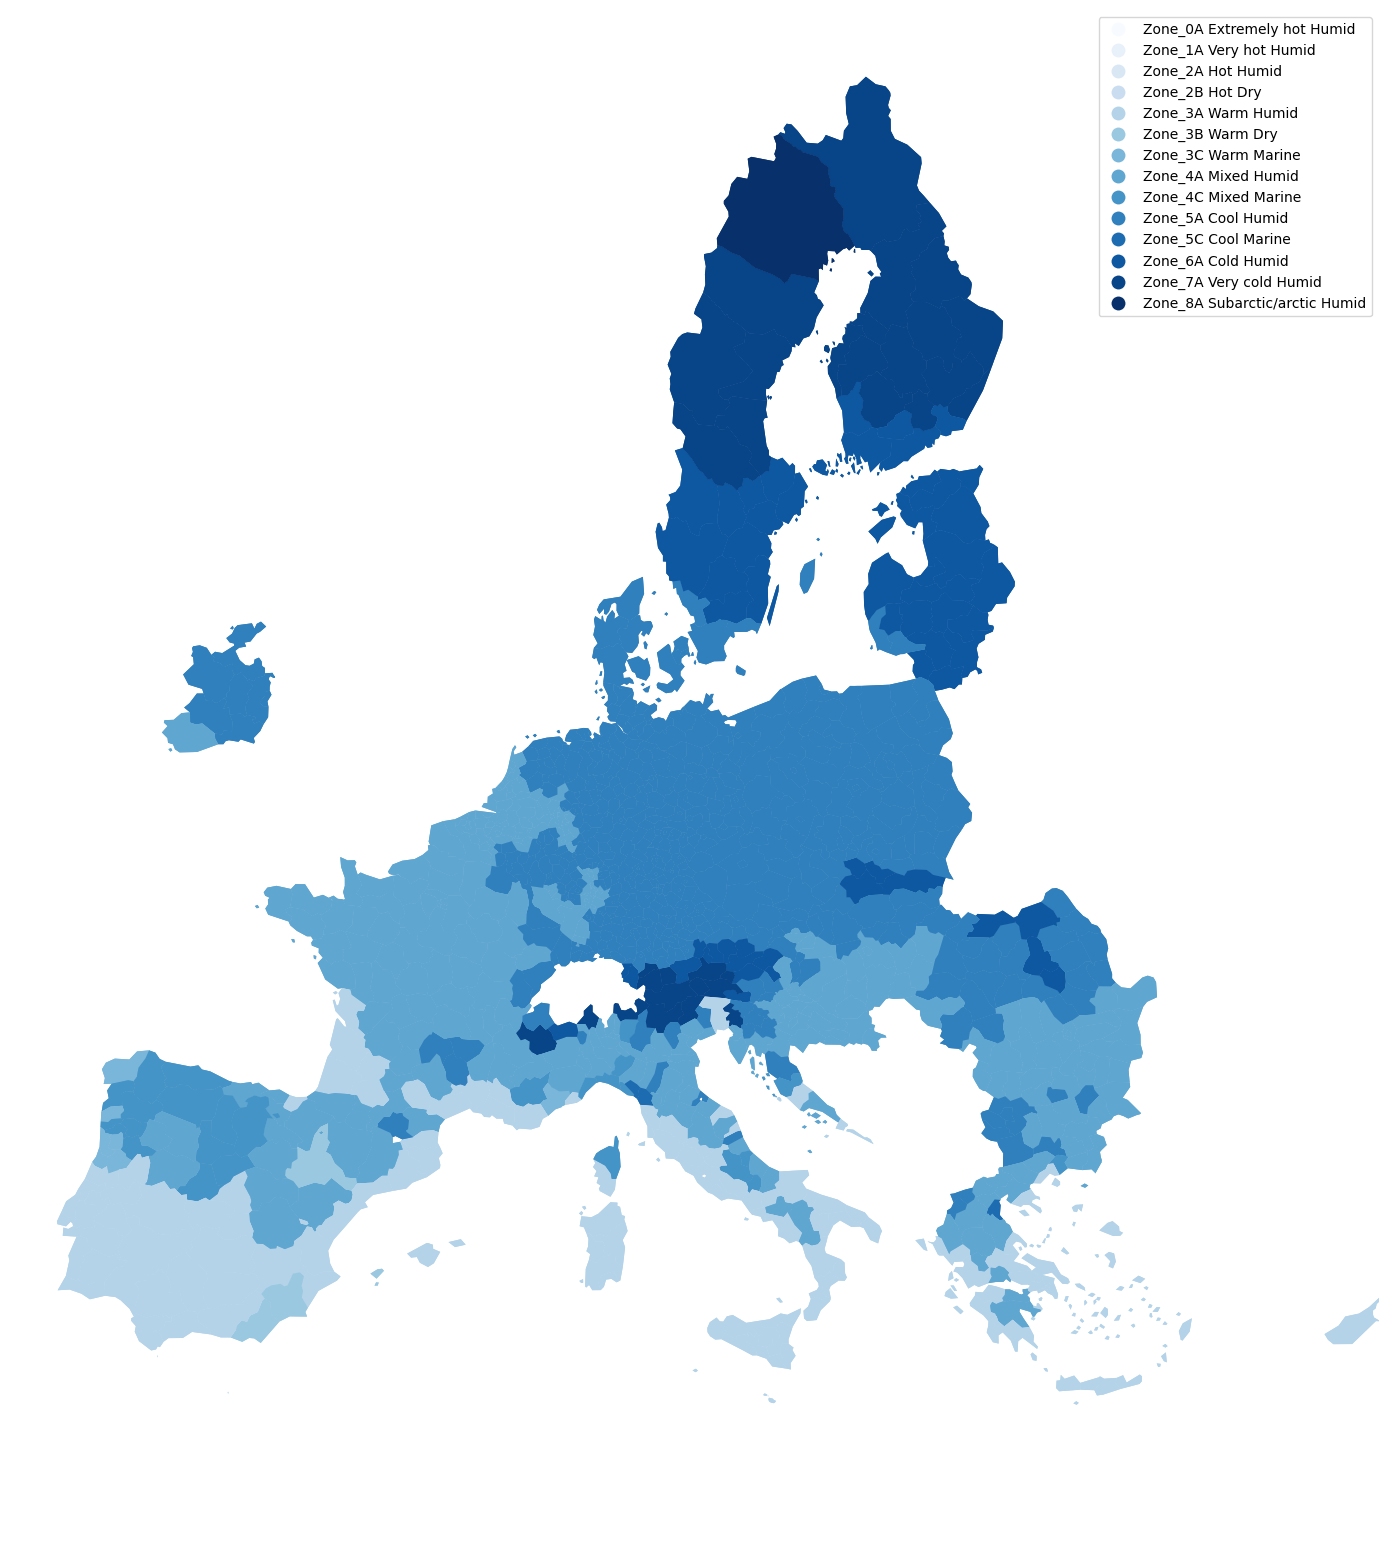

In [27]:
    file = 'climatic_zones_rev_nuts.csv'
    df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
    #merging shape with data
    df['NUTS_ID'] = df.region_nuts.str[10:]
    df_gdf = pd.merge(df, nuts, on='NUTS_ID')
    #year = 2050
    gdf = gpd.GeoDataFrame(df_gdf)
    col = 'clim'
    ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
                #cmap='RdBu_r', 
                cmap='Blues', #inferno_r
                #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
                #norm=custom_norm, 
                edgecolor=None,
                missing_kwds={'color': 'lightgrey'},
                #legend_kwds={"shrink":.5},
                )
    #ax.figure.axes[1].tick_params(labelsize=20)
    ax.set_xlim(0.25e7, 0.65e7)
    ax.set_ylim(1e6, 5.5e6)
    ax.set_axis_off()
    plt.savefig('plots/map_'+file[0:8]+'_'+str(year)+'.png')
    plt.show()

In [28]:
    #calculating dwelling weights of dwellings in NUTS per country
    pop = pd.read_csv('data/input_csv_NUTS_2025_resid/pop_clim_rev_SSP2_nuts.csv')
    pop['mat'] = 'perm'
    hhsize = pd.read_csv('data/input_csv_NUTS_2025_resid/hh_size_rev_nuts.csv')
    hhsize['mat'] = 'perm'
    hhsize = hhsize.set_index(keys=hhsize.columns.drop('value').to_list())
    arch_shr = pd.read_csv('data/input_csv_NUTS_2025_resid/bld_shr_arch_resid_nuts.csv')
    arch_shr = arch_shr.set_index(keys=arch_shr.columns.drop('value').to_list())

    dwellings = pop.groupby(by=pop.columns.drop(['clim','value']).to_list()).sum(numeric_only=True).mul(1e6).div(hhsize).fillna(method='bfill') #.div((hhsize*arch_shr).groupby(level=[0,1,2,4,5]).sum()).fillna(method='bfill')

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_51788/335572265.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dwellings = pop.groupby(by=pop.columns.drop(['clim','value']).to_list()).sum(numeric_only=True).mul(1e6).div(hhsize).fillna(method='bfill') #.div((hhsize*arch_shr).groupby(level=[0,1,2,4,5]).sum()).fillna(method='bfill')


In [27]:
    #calculating dwelling weights of dwellings in NUTS per country
    pop_ = pd.read_csv('data/input_csv_NUTS_2025_resid/pop_clim_rev_SSP2_nuts_bld.csv')
    pop_['mat'] = 'perm'
    hhsize_ = pd.read_csv('data/input_csv_NUTS_2025_resid/hh_size_rev_nuts_bld.csv')
    hhsize_['mat'] = 'perm'
    hhsize_ = hhsize_.set_index(keys=hhsize_.columns.drop('value').to_list())
    arch_shr_ = pd.read_csv('data/input_csv_NUTS_2025_resid/bld_shr_arch_resid_nuts_bld.csv')
    arch_shr_ = arch_shr_.set_index(keys=arch_shr_.columns.drop('value').to_list())

    dwellings_ = pop_.groupby(by=pop_.columns.drop(['clim','value']).to_list()).sum(numeric_only=True).mul(1e6).div(hhsize_).fillna(method='bfill')

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_51788/3491701205.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dwellings_ = pop_.groupby(by=pop_.columns.drop(['clim','value']).to_list()).sum(numeric_only=True).mul(1e6).div(hhsize_).fillna(method='bfill')


In [29]:
dwellings_.xs(2020, level='year').groupby('region_bld').sum() / dwellings.xs(2020, level='year').groupby('region_bld').sum()

,value
region_bld,
C-EEU-BGR,1.00
C-EEU-CZE,1.00
C-EEU-EST,1.00
C-EEU-HRV,1.00
C-EEU-HUN,1.00
C-EEU-LTU,1.00
C-EEU-LVA,1.00
C-EEU-POL,1.00
C-EEU-ROU,1.00


In [34]:
file = 'stock_baseyear_resid_rev_share_nuts_bld.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
df.groupby(by=df.columns.drop(['value', 'yr_con', 'bld_age']).to_list()).sum()

yr_con  \
region_bld region_gea urt clim                           mat  arch           
C-EEU-BGR  EEU        rur Zone_4A Mixed Humid            perm mfh    27815   
                                                              sfh    27815   
                          Zone_5A Cool Humid             perm mfh    27815   
                                                              sfh    27815   
                      urb Zone_4A Mixed Humid            perm mfh    27815   
...                                                                    ...   
C-WEU-SWE  WEU        urb Zone_6A Cold Humid             perm sfh    27815   
                          Zone_7A Very cold Humid        perm mfh    27815   
                                                              sfh    27815   
                          Zone_8A Subarctic/arctic Humid perm mfh    27815   
                                                              sfh    27815   

                                                                                         bld_age  \
region_bld region_gea urt clim                           mat  arch                                 
C-EEU-BGR  EEU        rur Zone_4A Mixed Humid            perm mfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
                                                              sfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
                          Zone_5A Cool Humid             perm mfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
                                                              sfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
                      urb Zone_4A Mixed Humid            perm mfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
...                                                                                          ...   
C-WEU-SWE  WEU        urb Zone_6A Cold Humid             perm sfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
                          Zone_7A Very cold Humid        perm mfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
                                                              sfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
                          Zone_8A Subarctic/arctic Humid perm mfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   
                                                              sfh   p1p2p2p2p2p2p2p2p3p3p3p3p3p3   

                                                                    value  
region_bld region_gea urt clim                           mat  arch         
C-EEU-BGR  EEU        rur Zone_4A Mixed Humid            perm mfh    0.60  
                                                              sfh    0.60  
                          Zone_5A Cool Humid             perm mfh    0.40  
                                                              sfh    0.40  
                      urb Zone_4A Mixed Humid            perm mfh    0.65  
...                                                                   ...  
C-WEU-SWE  WEU        urb Zone_6A Cold Humid             perm sfh    0.64  
                          Zone_7A Very cold Humid        perm mfh    0.12  
                                                              sfh    0.12  
                          Zone_8A Subarctic/arctic Humid perm mfh    0.03  
                                                              sfh    0.03  

[308 rows x 3 columns]

In [26]:
file = 'bld_shr_arch_resid_nuts.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
df.groupby(by=df.columns.drop(['value', 'arch']).to_list()).sum()

arch  value
region_bld region_nuts     urt mat  year               
C-EEU-BGR  C-EEU-BGR-BG311 rur perm 2015  mfhsfh   1.00
                                    2020  mfhsfh   1.00
                                    2025  mfhsfh   1.00
                                    2030  mfhsfh   1.00
                                    2035  mfhsfh   1.00
...                                          ...    ...
C-WEU-SWE  C-WEU-SWE-SE332 urb perm 2080  mfhsfh   1.00
                                    2085  mfhsfh   1.00
                                    2090  mfhsfh   1.00
                                    2095  mfhsfh   1.00
                                    2100  mfhsfh   1.00

[41940 rows x 2 columns]

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_14026/2933684970.py:11: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df = df.groupby(by=['region_nuts', 'year', 'arch'], axis=0).mean(numeric_only=True).reset_index()


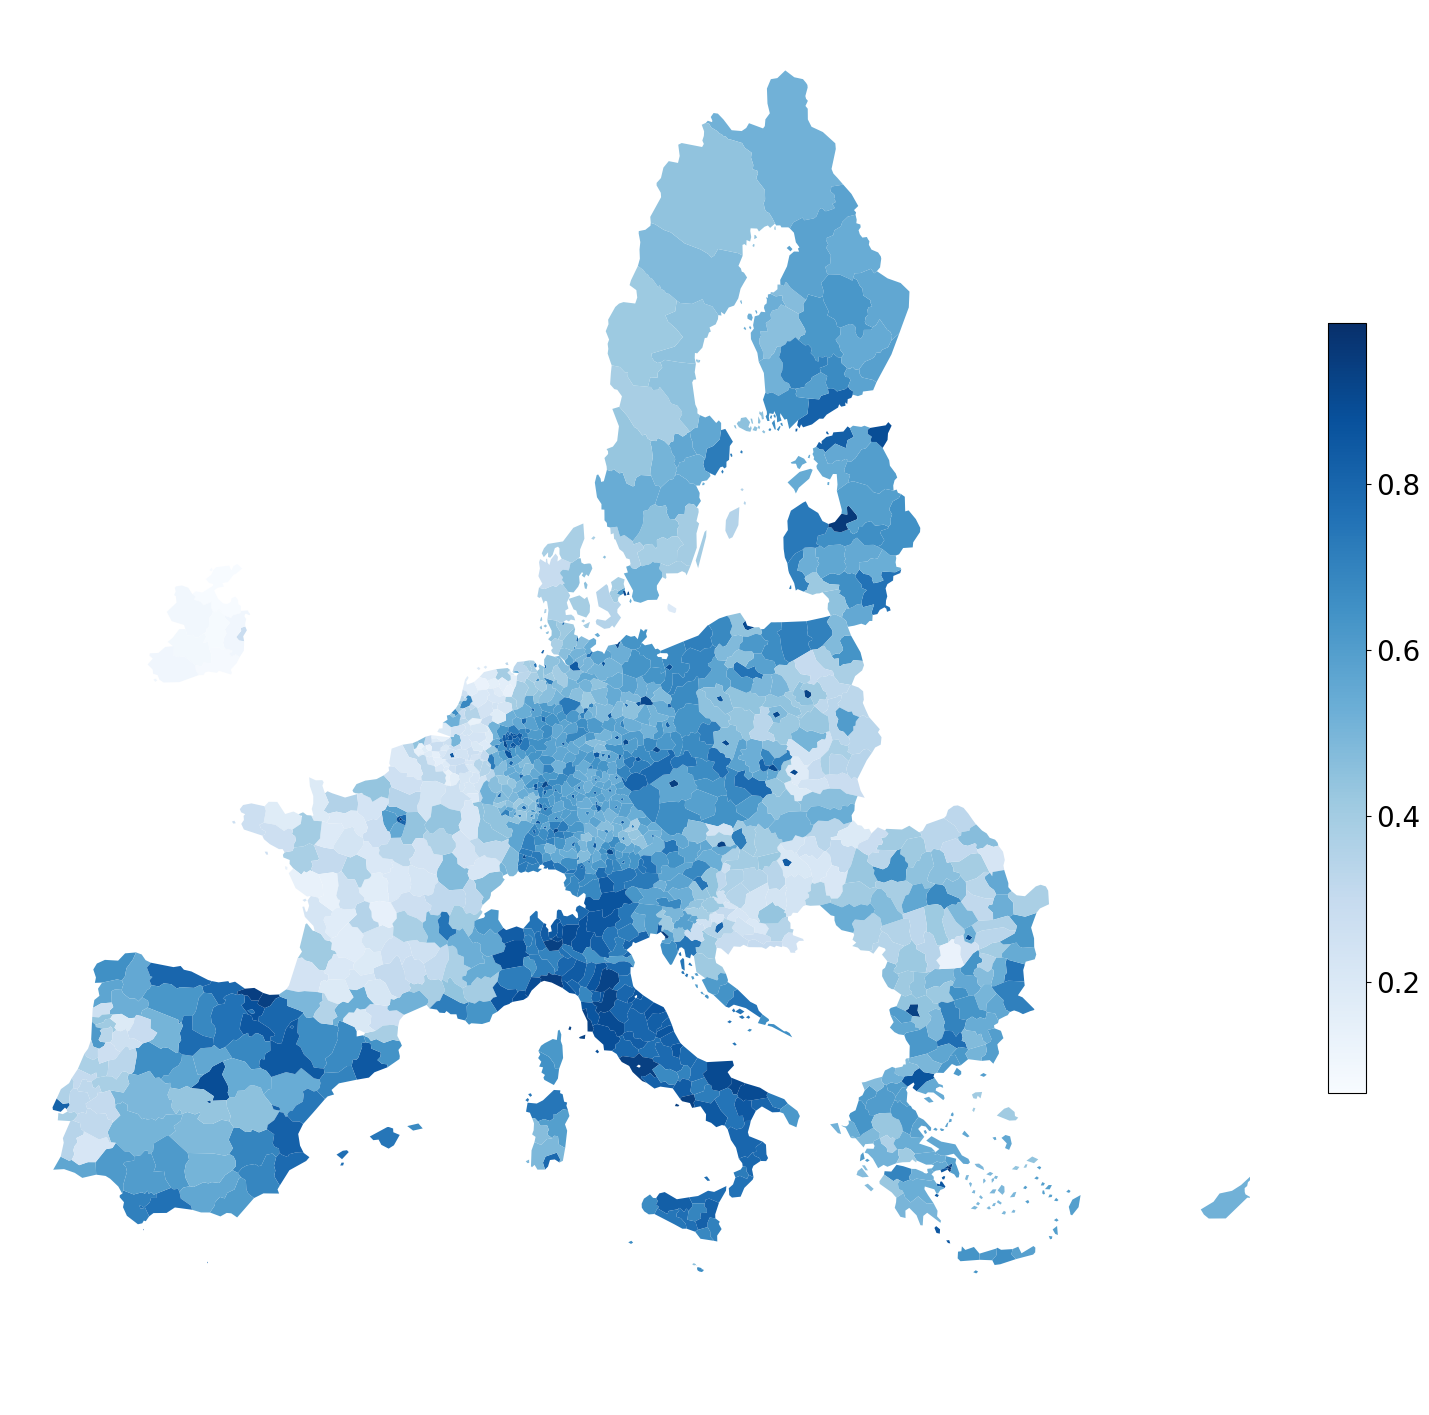

In [9]:
file = 'bld_shr_arch_resid_nuts.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
if geo==False:
    for i in df.columns.drop(['region_nuts', 'value']):
        hue=i
        sns.histplot(data=df, x='value', hue=hue)
        plt.savefig('plots/'+file[0:8]+hue+'.png')
        plt.show()
        plt.close()
else:
    df = df.groupby(by=['region_nuts', 'year', 'arch'], axis=0).mean(numeric_only=True).reset_index()

    #merging shape with data
    df['NUTS_ID'] = df.region_nuts.str[10:]
    df_gdf = pd.merge(df, nuts, on='NUTS_ID')

    year = 2050
    gdf = gpd.GeoDataFrame(df_gdf[(df_gdf['year']==year) & (df_gdf['arch']=='mfh')])
    col = 'value'
    ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
                #cmap='RdBu_r', 
                cmap='Blues', #inferno_r
                #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
                #norm=custom_norm, 
                edgecolor=None,
                missing_kwds={'color': 'lightgrey'},
                legend_kwds={"shrink":.5},)
    ax.figure.axes[1].tick_params(labelsize=20)
    ax.set_xlim(0.25e7, 0.65e7)
    ax.set_ylim(1e6, 5.5e6)
    ax.set_axis_off()
    plt.savefig('plots/map_'+file[0:8]+'_'+str(year)+'.png')
    plt.show()

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_22688/665163666.py:11: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df = df.groupby(by=['region_nuts'], axis=0).mean(numeric_only=True).reset_index()


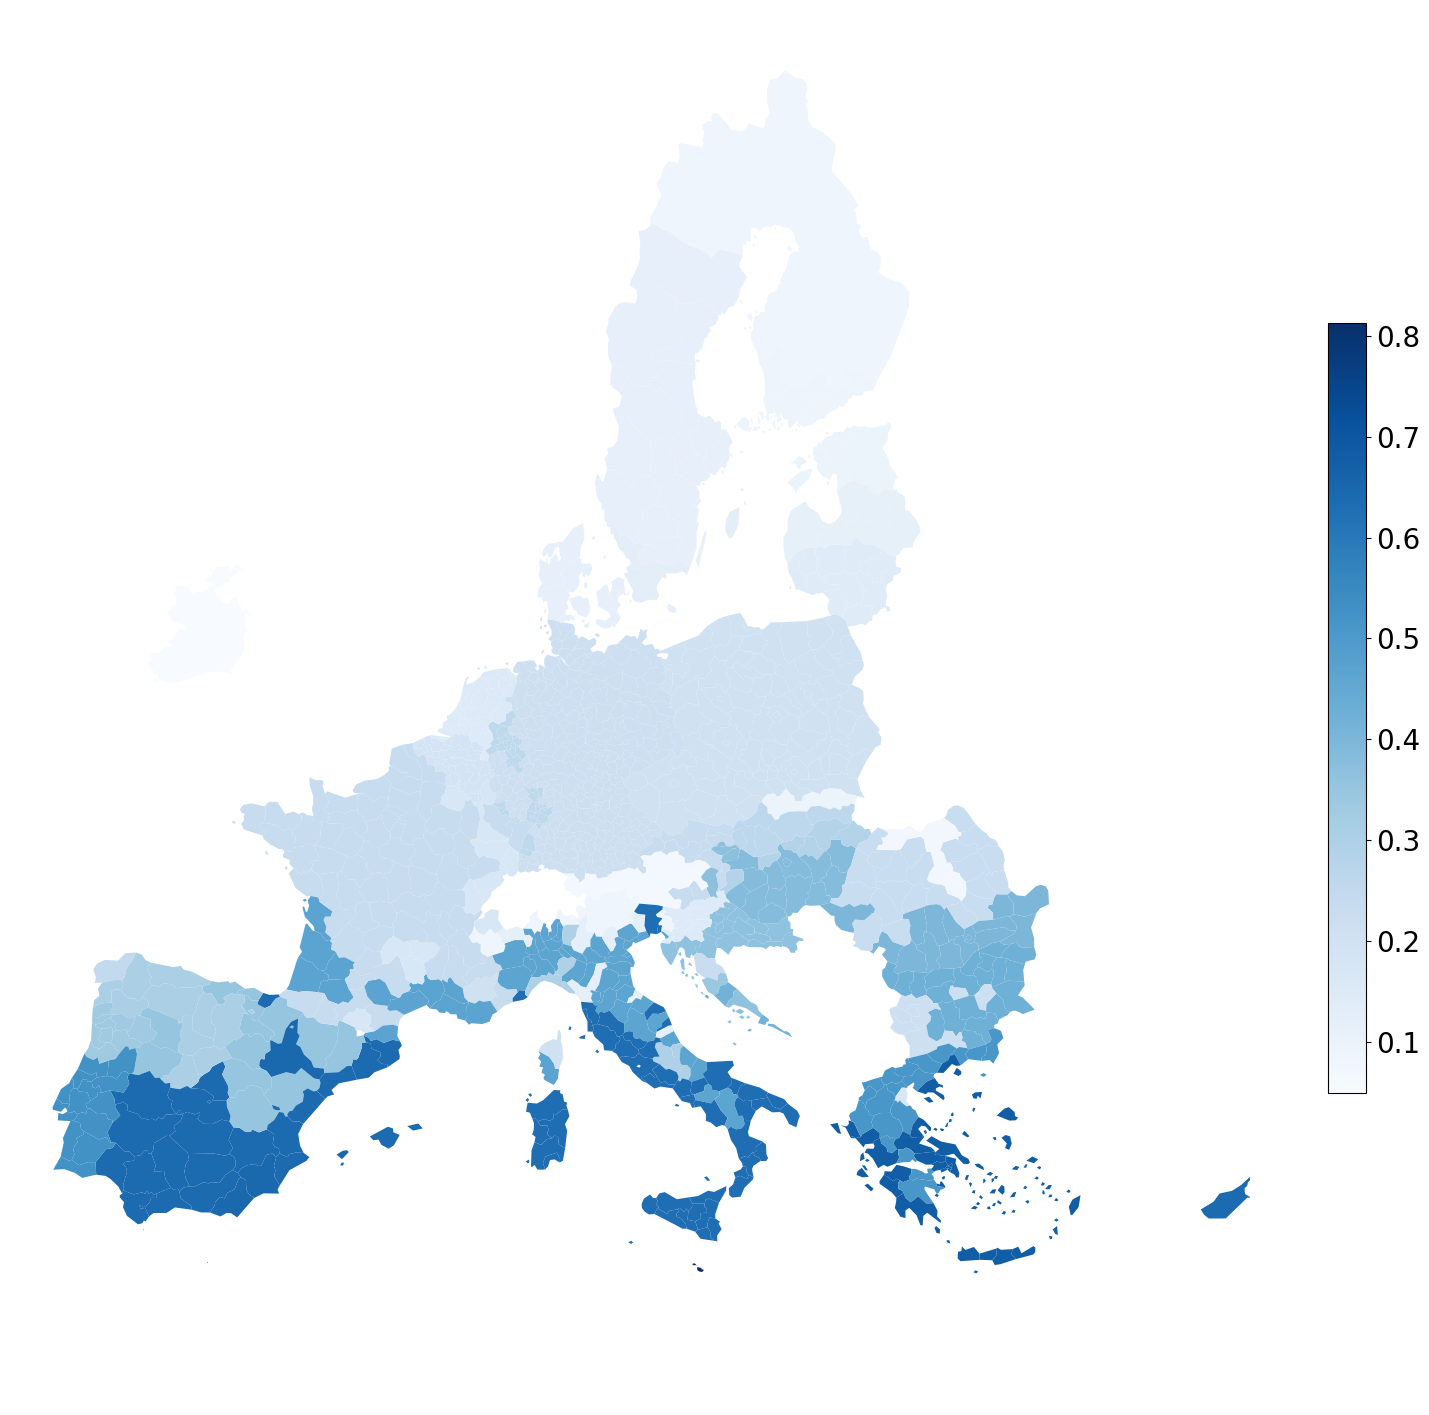

In [11]:
file = 'bld_shr_access_cool_resid_ssp2_rev_nuts.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
if geo==False:
    for i in df.columns.drop(['region_nuts', 'value']):
        hue=i
        sns.histplot(data=df, x='value', hue=hue)
        plt.savefig('plots/'+file[0:8]+hue+'.png')
        plt.show()
        plt.close()
else:
    df = df.groupby(by=['region_nuts'], axis=0).mean(numeric_only=True).reset_index()

    #merging shape with data
    df['NUTS_ID'] = df.region_nuts.str[10:]
    df_gdf = pd.merge(df, nuts, on='NUTS_ID')

    year = 2050
    gdf = gpd.GeoDataFrame(df_gdf)
    col = 'value'
    ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
                #cmap='RdBu_r', 
                cmap='Blues', #inferno_r
                #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
                #norm=custom_norm, 
                edgecolor=None,
                missing_kwds={'color': 'lightgrey'},
                legend_kwds={"shrink":.5},)
    ax.figure.axes[1].tick_params(labelsize=20)
    ax.set_xlim(0.25e7, 0.65e7)
    ax.set_ylim(1e6, 5.5e6)
    ax.set_axis_off()
    plt.savefig('plots/map_'+file[0:8]+'.png')
    plt.show()

## Material demand NUTS0 vs NUTS3
-  (bar chart) – total difference
- (map) geographical distribution, e.g. cities more or less than rural, individual cities more similar to other countries than their own
- (distribution plots) – more exploratory analysis of potential correlates (population size, population trend, economic growth etc.)

<Axes: xlabel='year', ylabel='floor_tot_Mm2'>

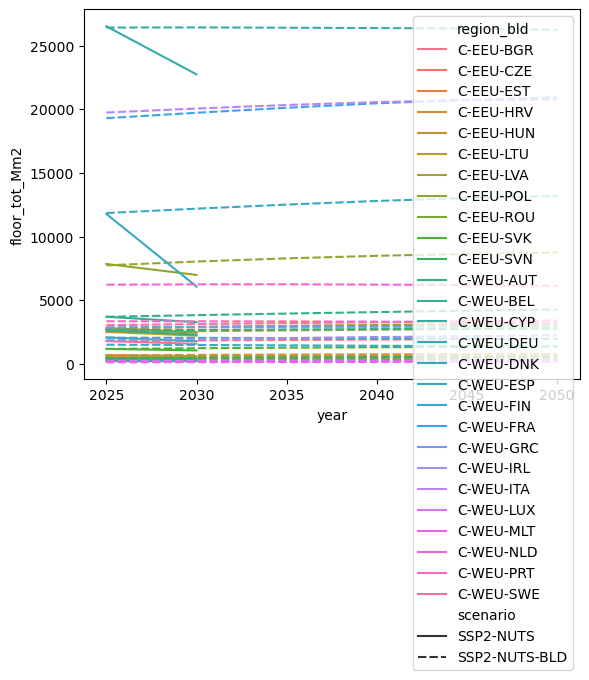

In [9]:
#data
mat = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_material.csv")
mat['region_bld'] = mat.region_nuts.str[0:9]
mat_nuts = mat.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

mat = pd.read_csv("output/report_STURM_SSP2-NUTS-BLD_resid_region_bld_material.csv")
mat_bld = mat.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

mat = pd.concat([mat_nuts, mat_bld], axis=0)

sns.lineplot(data=mat.floor_tot_Mm2.reset_index(), x="year", y="floor_tot_Mm2", hue="region_bld", style="scenario")

In [3]:
#data
mat = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_energy.csv")
mat['region_bld'] = mat.region_nuts.str[0:9]
mat_nuts = mat.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

mat = pd.read_csv("output/report_STURM_SSP2-NUTS-BLD_resid_region_bld_energy.csv")
mat_bld = mat.groupby(by=['region_bld', 'scenario', 'year']).sum(numeric_only=True)

mat = pd.concat([mat_nuts, mat_bld], axis=0)

In [6]:
mat = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_energy.csv")
mat_ = pd.read_csv("output/report_STURM_SSP2-NUTS-BLD_resid_region_bld_energy.csv")

In [7]:
mat_.loc[:,:'floor_Mm2'].sum(axis=0, numeric_only=True)

year        298,937,760.00
stock_M           1,388.45
floor_Mm2       130,003.92
dtype: float64

In [8]:
mat.loc[:,:'floor_Mm2'].sum(axis=0, numeric_only=True)

year        4,509,790,020.00
stock_M             1,389.12
floor_Mm2         130,096.42
dtype: float64

(0.0, 19265.19667119256)

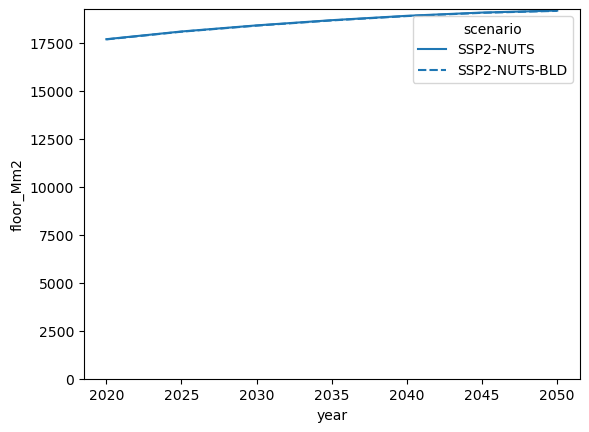

In [5]:
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).floor_Mm2.reset_index(), x="year", y="floor_Mm2", style="scenario")
ax.set_ylim(bottom=0)

<Axes: xlabel='year', ylabel='stock_M'>

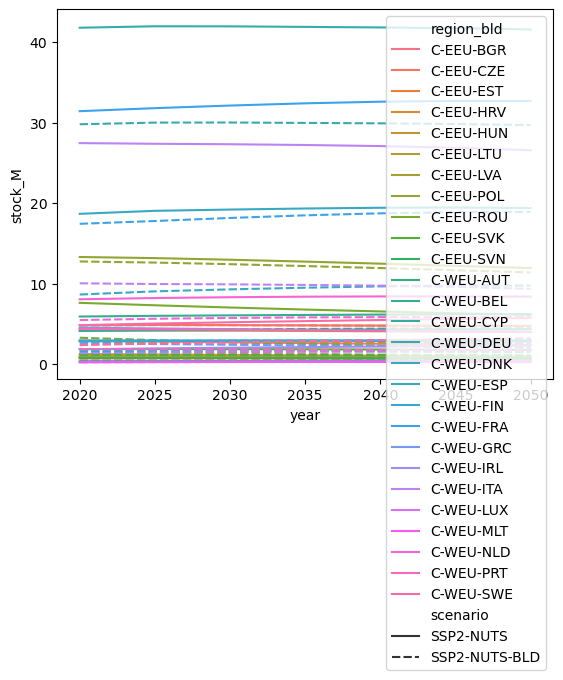

In [5]:
sns.lineplot(data=mat.stock_M.reset_index(), x="year", y="stock_M", hue="region_bld", style="scenario")

<Axes: xlabel='year', ylabel='pc_diff'>

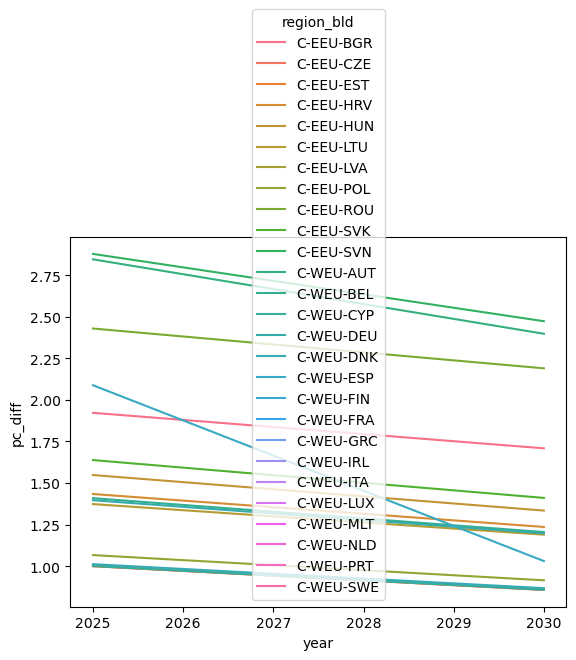

In [8]:
floor_tot_Mm2 = mat.floor_tot_Mm2.unstack(1)
floor_tot_Mm2['pc_diff'] = floor_tot_Mm2['SSP2-NUTS'] / floor_tot_Mm2['SSP2-NUTS-BLD'] 
sns.lineplot(data=floor_tot_Mm2.pc_diff.reset_index(), x="year", y="pc_diff", hue="region_bld")

(0.0, 138160.5091620971)

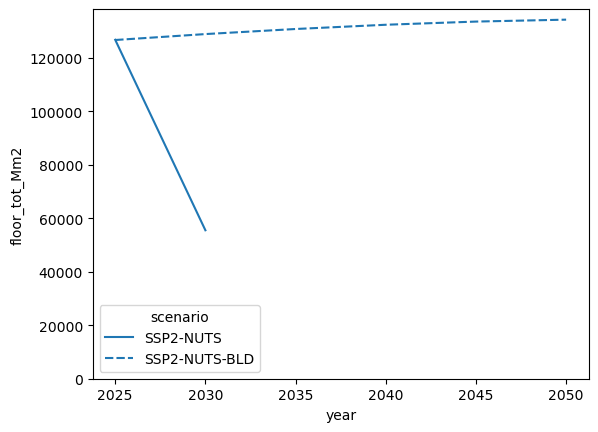

In [10]:
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).floor_tot_Mm2.reset_index(), x="year", y="floor_tot_Mm2", style="scenario")
ax.set_ylim(bottom=0)

(0.0, 1300.3198237458828)

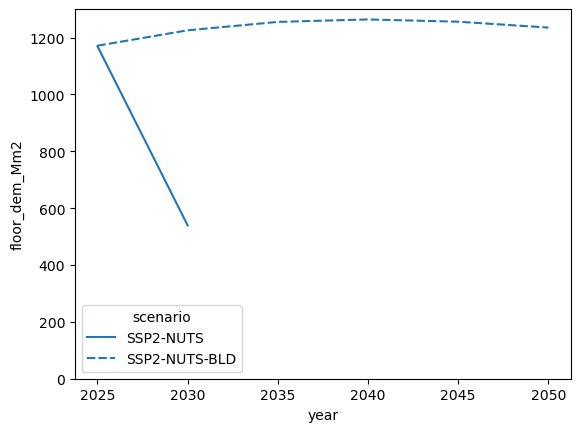

In [11]:
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).floor_dem_Mm2.reset_index(), x="year", y="floor_dem_Mm2", style="scenario")
ax.set_ylim(bottom=0)

(0.0, 1465.580969996572)

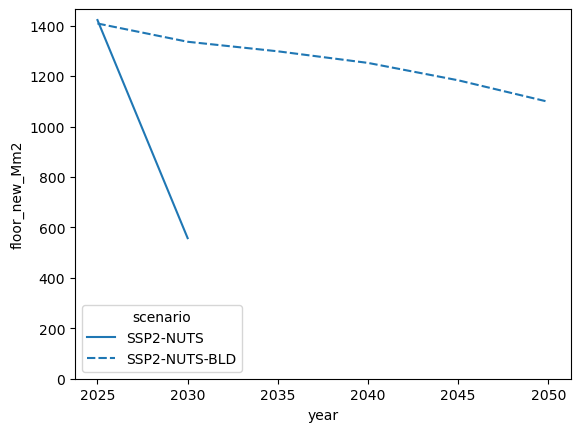

In [12]:
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).floor_new_Mm2.reset_index(), x="year", y="floor_new_Mm2", style="scenario")
ax.set_ylim(bottom=0)

(0.0, 235.7388191708365)

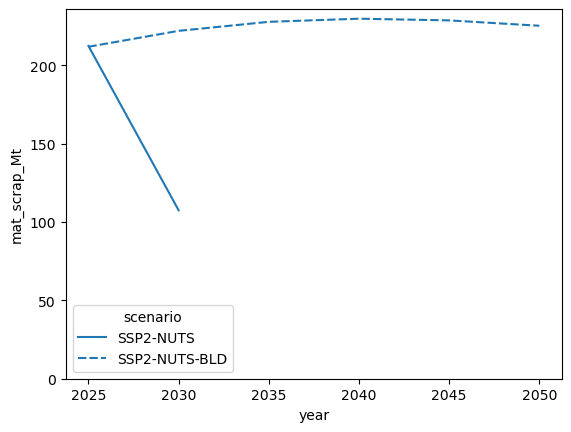

In [13]:
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).mat_scrap_Mt.reset_index(), x="year", y="mat_scrap_Mt", style="scenario")
ax.set_ylim(bottom=0)

(0.0, 25073.311142389703)

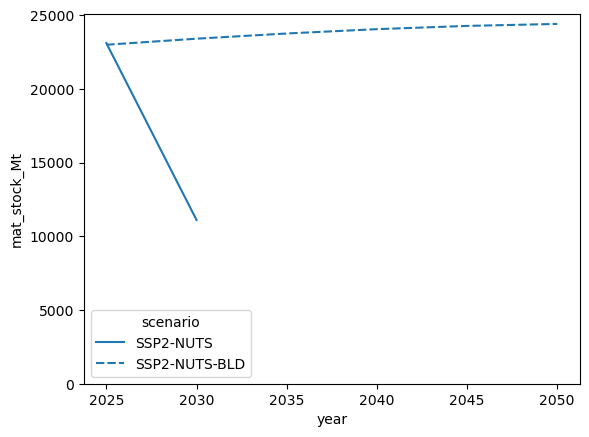

In [14]:
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True).mat_stock_Mt.reset_index(), x="year", y="mat_stock_Mt", style="scenario")
ax.set_ylim(bottom=0)

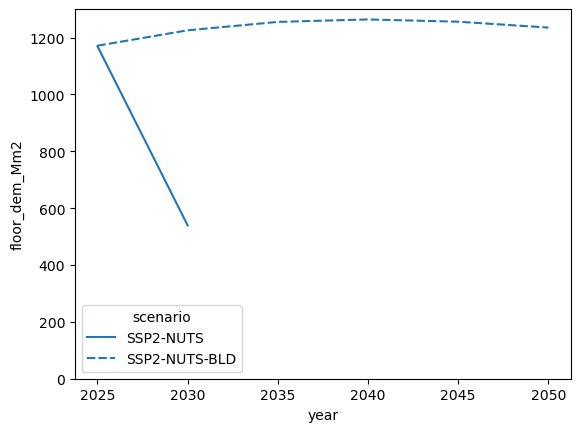

In [15]:
col = "floor_dem_Mm2"
ax = sns.lineplot(data=mat.groupby(level=[1,2]).sum(numeric_only=True)[col].reset_index(), x="year", y=col, style="scenario")
ax.set_ylim(bottom=0)
plt.savefig('plots/lines_'+col+'.png', bbox_inches='tight')

In [16]:
#data import
file = 'hh_size_rev_nuts'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file+".csv")
df2 = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file+"_bld.csv")
pd.concat([df.groupby('year').mean(numeric_only=True), df2.groupby('year').mean(numeric_only=True)], keys=['nuts', 'bld']).unstack()

value                                                                   \
year  2015 2020 2025 2030 2035 2040 2045 2050 2055 2060 2065 2070 2075 2080   
nuts  2.31 2.31 2.31 2.31 2.31 2.31 2.31 2.31 2.31 2.31 2.31 2.31 2.31 2.31   
bld   2.43 2.43 2.44 2.44 2.44 2.44 2.44 2.44 2.44 2.44 2.44 2.44 2.44 2.44   

                          
year 2085 2090 2095 2100  
nuts 2.31 2.31 2.31 2.31  
bld  2.44 2.44 2.44 2.44

In [17]:
#data import
file = 'pop_clim_rev_SSP2_nuts.csv'
df = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)

file = 'pop_clim_rev_SSP2_nuts_bld.csv'
df2 = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
pd.concat([df.groupby('year').sum(numeric_only=True), df2.groupby('year').sum(numeric_only=True)], keys=['nuts', 'bld']).unstack()

value                                                                 \
year   2020   2025   2030   2035   2040   2045   2050   2055   2060   2065   
nuts 450.18 451.92 451.81 451.01 449.64 447.47 444.35 440.33 435.82 431.48   
bld  450.18 451.92 451.81 451.01 449.64 447.47 444.35 440.33 435.82 431.48   

                                                       
year   2070   2075   2080   2085   2090   2095   2100  
nuts 427.82 424.98 422.83 421.29 420.30 419.80 419.59  
bld  427.82 424.98 422.83 421.29 420.30 419.80 419.59

In [14]:
#data
ene = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_energy.csv")
mat = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_material.csv")

#only region and year
ene = ene.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True) #also summing across fuels
mat = mat.groupby(by=['region_nuts', 'year', 'material'], axis=0).sum(numeric_only=True) #also summing across materials

#ene = ene.xs('electricity', level='fuel_cool').xs('gas', level='fuel_heat').reset_index()
mat = mat.xs('concrete', level='material').reset_index()

#normalising all results by population
file = 'pop_clim_rev_SSP2_nuts.csv'
pop = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
pop = pop.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).reset_index()
pop.columns = ['region_nuts', 'year', 'pop_M']
ene = pd.merge(ene, pop, on=['region_nuts', 'year'], how='left')
ene = ene.set_index(['region_nuts','year'])
ene = ene.div(ene['pop_M'], axis=0).reset_index() #per capita
mat = pd.merge(mat, pop, on=['region_nuts', 'year'], how='left')
mat = mat.set_index(['region_nuts','year'])
mat = mat.div(mat['pop_M'], axis=0).reset_index() #per capita

#merging shape with data
ene['NUTS_ID'] = ene.region_nuts.str[10:]
mat['NUTS_ID'] = mat.region_nuts.str[10:]
ene_gdf = pd.merge(ene, nuts, on='NUTS_ID')
mat_gdf = pd.merge(mat, nuts, on='NUTS_ID')

/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_31430/3258938189.py:6: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  ene = ene.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True) #also summing across fuels
/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_31430/3258938189.py:7: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  mat = mat.groupby(by=['region_nuts', 'year', 'material'], axis=0).sum(numeric_only=True) #also summing across materials
/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_31430/3258938189.py:15: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  pop = pop.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).reset_index()


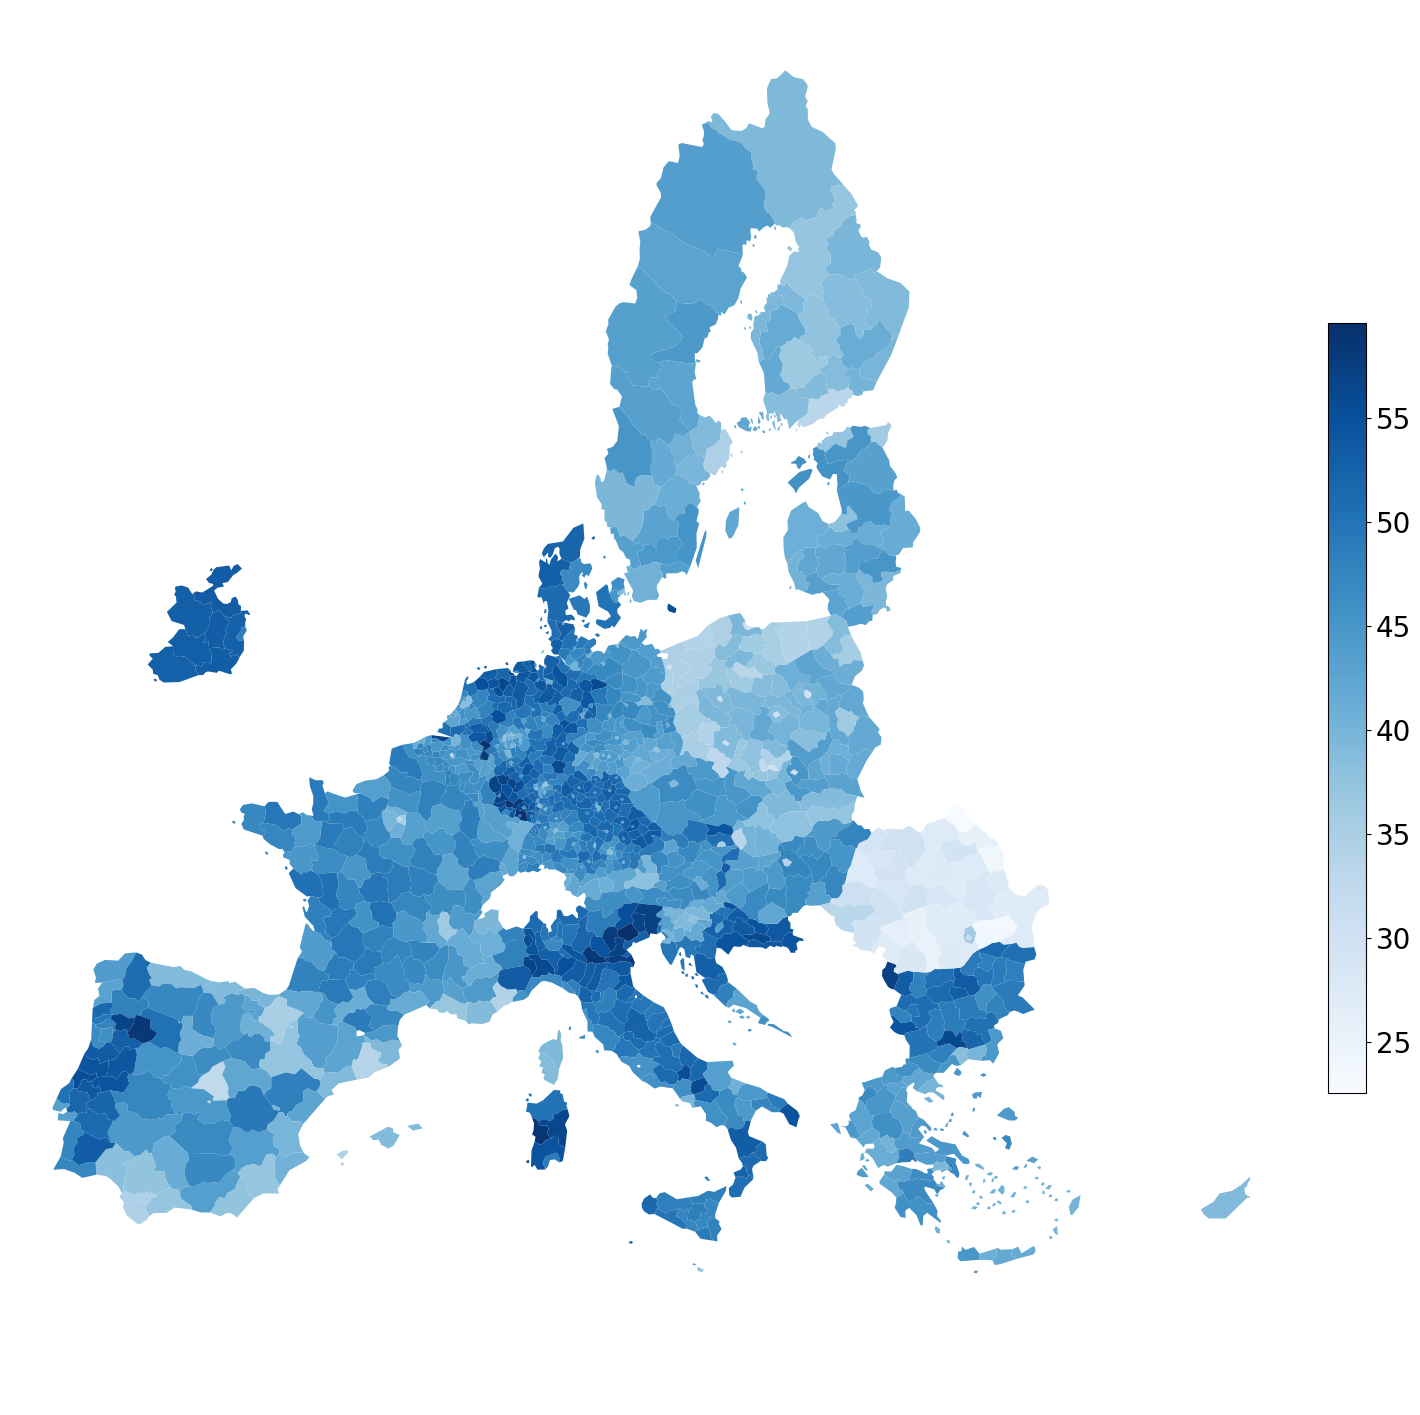

In [43]:
year = 2050
gdf = gpd.GeoDataFrame(ene_gdf[ene_gdf['year']==year])
#gdf = gpd.GeoDataFrame(ene_gdf)
col = 'floor_Mm2' #m2 per cap
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='Blues', #inferno_r
              #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
              #norm=custom_norm, 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
plt.savefig('plots/map_'+col+'_'+str(year)+'.png', bbox_inches='tight')

In [11]:

ene = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_energy.csv")
mat = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_material.csv")

#only region and year
ene = ene.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True) #also summing across fuels
mat = mat.groupby(by=['region_nuts', 'year', 'material'], axis=0).sum(numeric_only=True) #also summing across materials

#ene = ene.xs('electricity', level='fuel_cool').xs('gas', level='fuel_heat').reset_index()
mat = mat.xs('concrete', level='material').reset_index()

#normalising all results by population
file = 'pop_clim_rev_SSP2_nuts.csv'
pop = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
pop = pop.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).reset_index()
pop.columns = ['region_nuts', 'year', 'pop_M']
ene = pd.merge(ene, pop, on=['region_nuts', 'year'], how='left')
ene = ene.set_index(['region_nuts','year'])
ene = ene.div(ene['pop_M'], axis=0).reset_index() #per capita
mat = pd.merge(mat, pop, on=['region_nuts', 'year'], how='left')
mat = mat.set_index(['region_nuts','year'])
mat = mat.div(mat['pop_M'], axis=0).reset_index() #per capita

mat = mat.groupby('region_nuts').mean(numeric_only=True).reset_index()

#merging shape with data
ene['NUTS_ID'] = ene.region_nuts.str[10:]
mat['NUTS_ID'] = mat.region_nuts.str[10:]
ene_gdf = pd.merge(ene, nuts, on='NUTS_ID')
mat_gdf = pd.merge(mat, nuts, on='NUTS_ID')



/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_31430/3102442182.py:5: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  ene = ene.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True) #also summing across fuels
/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_31430/3102442182.py:6: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  mat = mat.groupby(by=['region_nuts', 'year', 'material'], axis=0).sum(numeric_only=True) #also summing across materials
/var/folders/__/twfrdq8n75n5f0118_f882700000gn/T/ipykernel_31430/3102442182.py:14: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  pop = pop.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).reset_index()


,region_nuts,year,floor_tot_Mm2,floor_new_Mm2,floor_dem_Mm2,mat_stock_Mt,mat_demand_Mt,mat_scrap_Mt,mat_int,pop_M,NUTS_ID
0,C-EEU-BGR-BG311,"2,037.50",50.83,0.00,0.67,72.72,0.00,0.94,"2,523,664.34",1.00,BG311
1,C-EEU-BGR-BG312,"2,037.50",47.29,0.04,0.58,67.87,0.06,0.82,"1,634,796.36",1.00,BG312
2,C-EEU-BGR-BG313,"2,037.50",42.78,0.02,0.54,60.69,0.02,0.75,"1,312,390.99",1.00,BG313
3,C-EEU-BGR-BG314,"2,037.50",44.97,0.06,0.55,61.41,0.07,0.74,"875,283.70",1.00,BG314
4,C-EEU-BGR-BG315,"2,037.50",45.68,0.06,0.55,65.32,0.07,0.77,"1,684,075.03",1.00,BG315
...,...,...,...,...,...,...,...,...,...,...,...
1160,C-WEU-SWE-SE313,"2,037.50",42.92,0.52,0.39,42.15,0.51,0.38,"389,406.23",1.00,SE313
1161,C-WEU-SWE-SE321,"2,037.50",44.75,0.48,0.43,43.71,0.46,0.42,"468,977.91",1.00,SE321
1162,C-WEU-SWE-SE322,"2,037.50",43.75,0.50,0.39,43.31,0.49,0.38,"852,144.30",1.00,SE322
1163,C-WEU-SWE-SE331,"2,037.50",42.99,0.54,0.38,41.40,0.52,0.37,"409,344.75",1.00,SE331


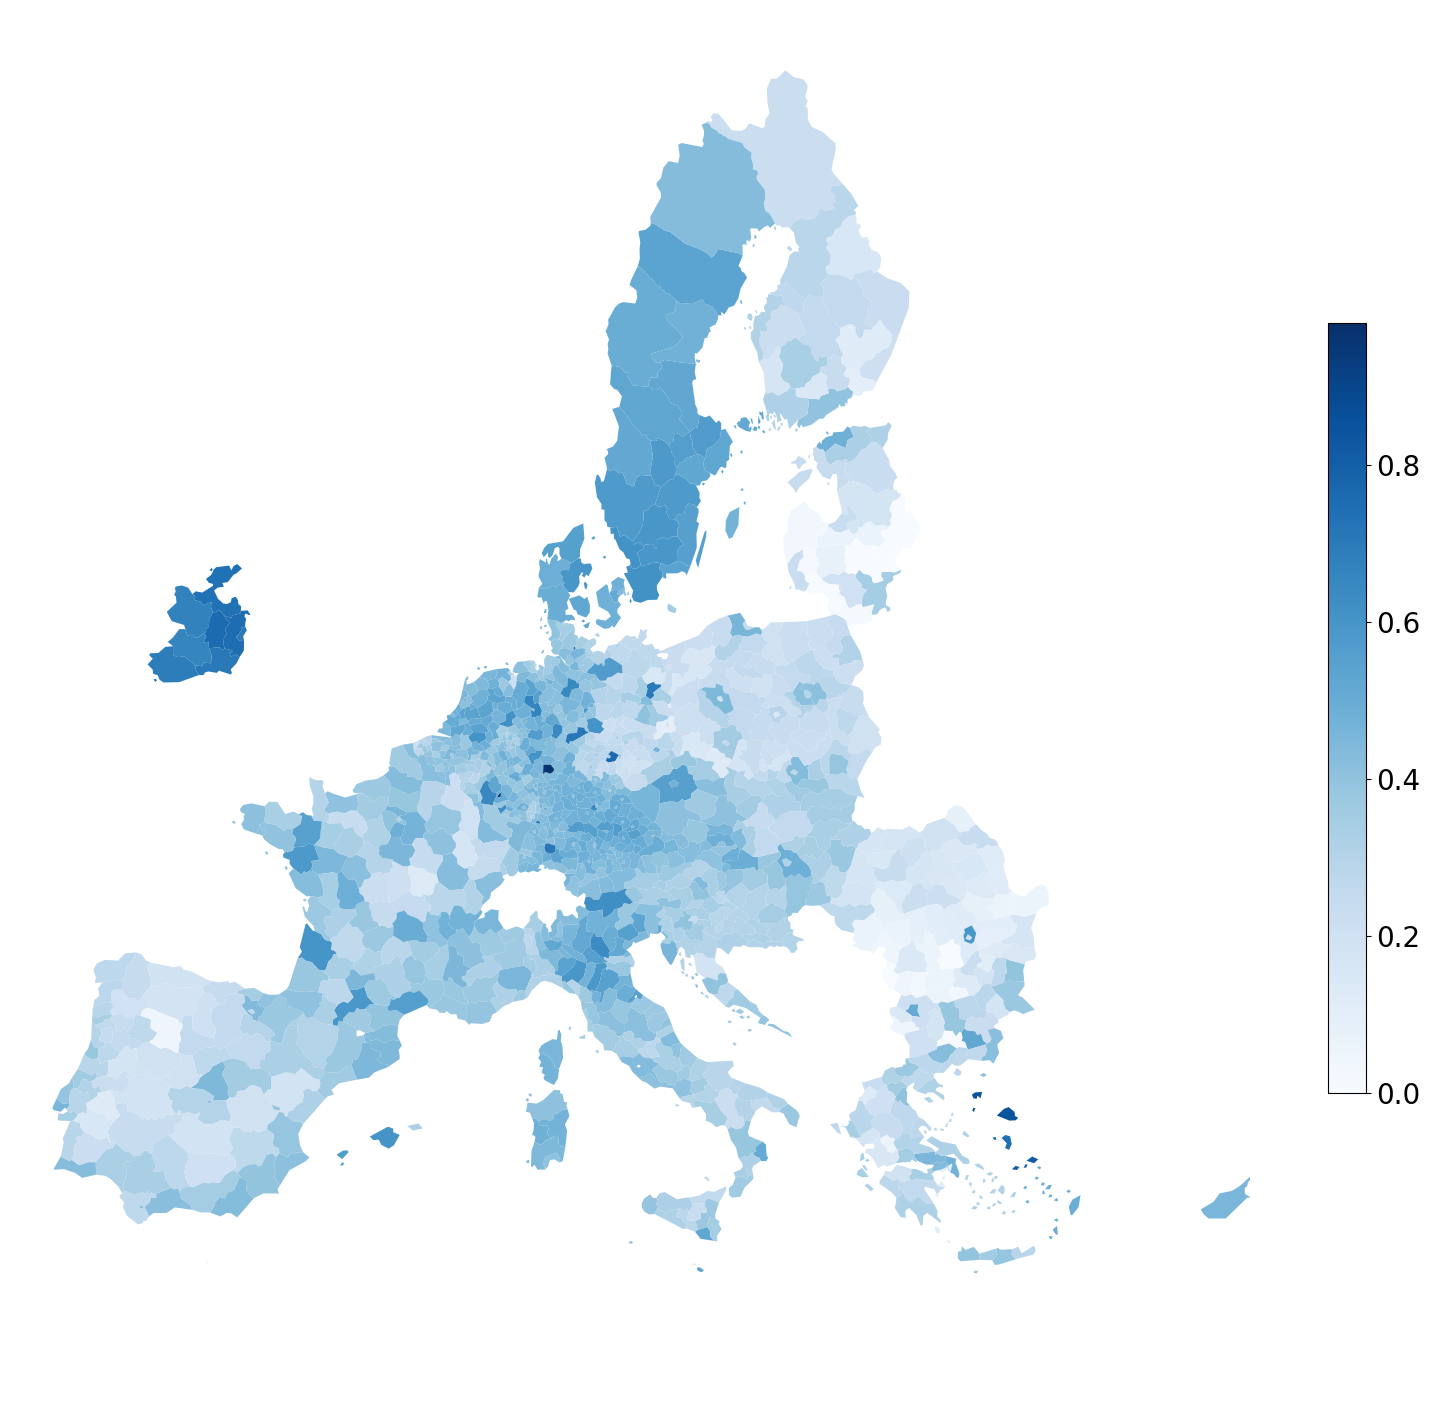

In [12]:
#year = 2050
gdf = gpd.GeoDataFrame(mat_gdf)
#gdf = gpd.GeoDataFrame(ene_gdf)
col = 'floor_new_Mm2' #m2 per cap
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='Blues', #inferno_r
              #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
              #norm=custom_norm, 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
plt.savefig('plots/map_'+col+'_'+str(year)+'.png', bbox_inches='tight')

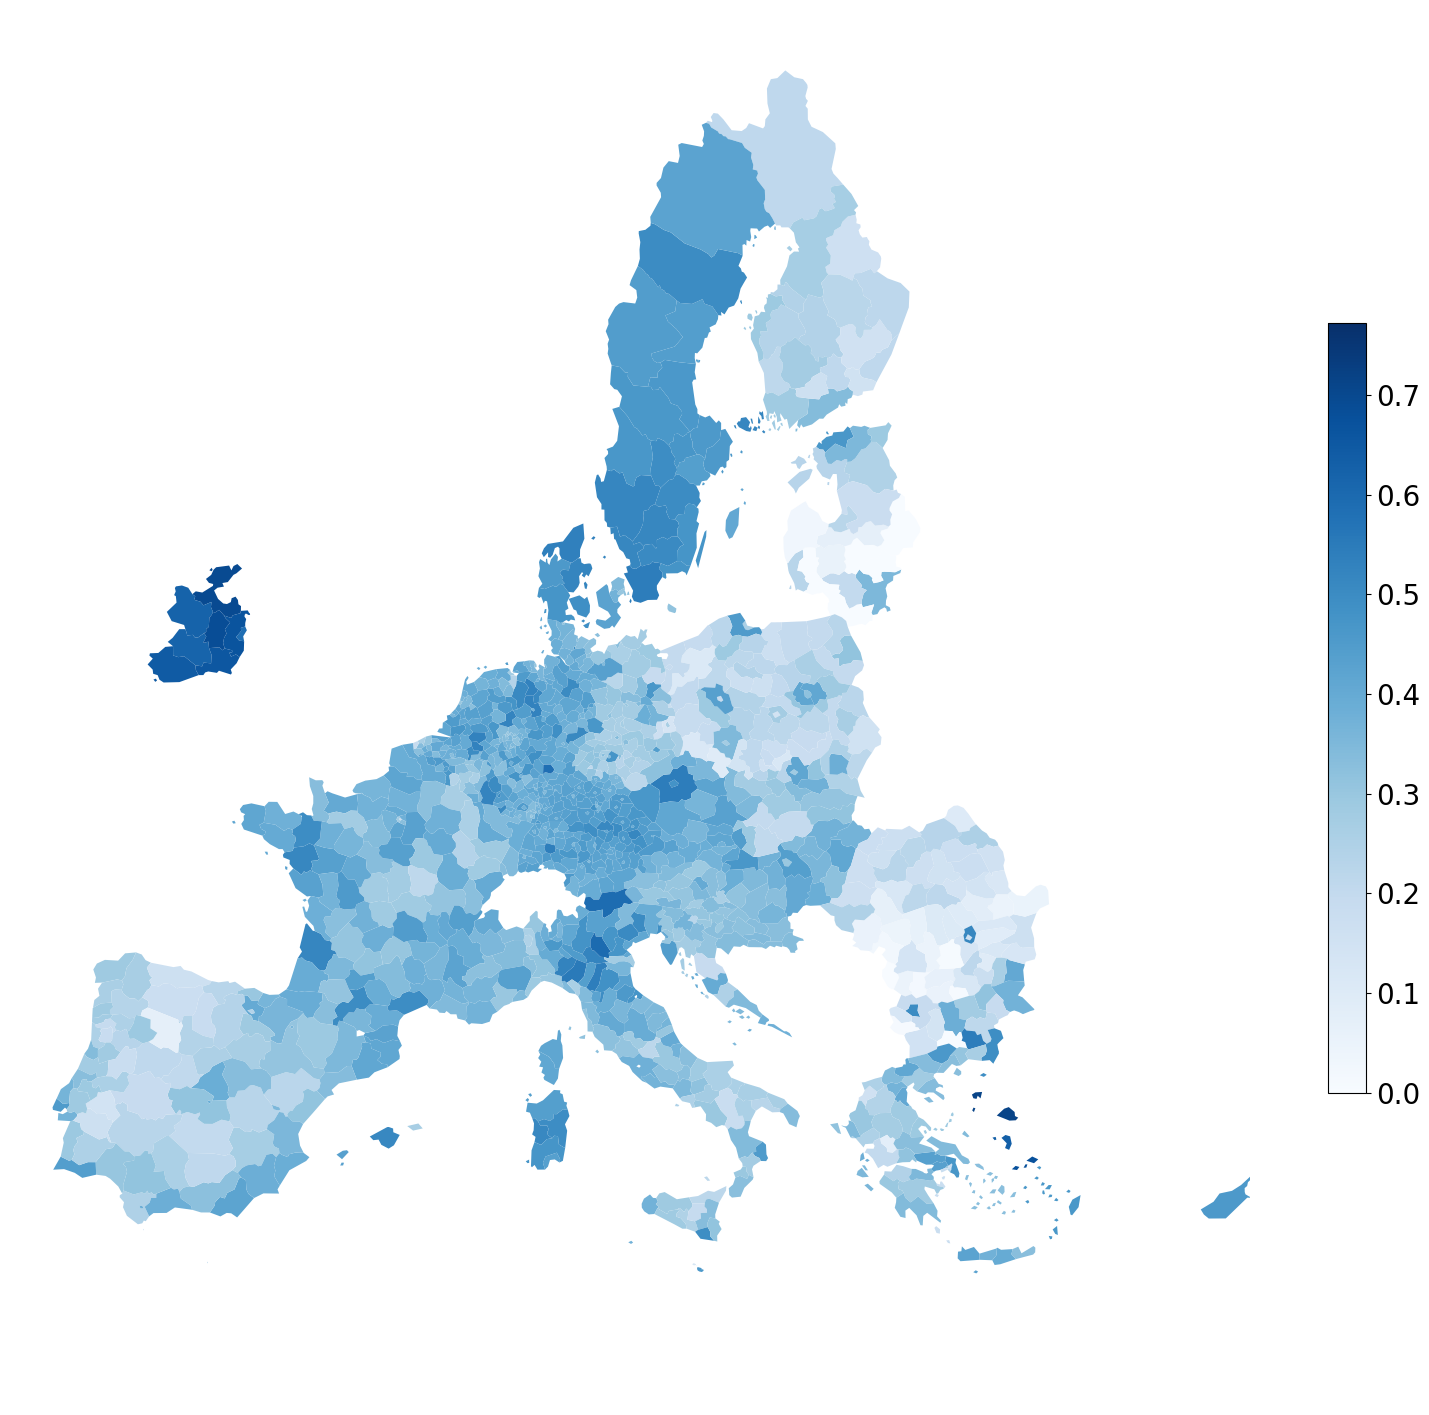

In [6]:
year = 2050
gdf = gpd.GeoDataFrame(mat_gdf[mat_gdf['year']==year])
#gdf = gpd.GeoDataFrame(ene_gdf)
col = 'floor_new_Mm2' #m2 per cap
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='Blues', #inferno_r
              #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
              #norm=custom_norm, 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
plt.savefig('plots/map_'+col+'_'+str(year)+'.png', bbox_inches='tight')

In [5]:
ene_gdf

,region_nuts,year,stock_M,floor_Mm2,heat_TJ,cool_TJ,cool_ac_TJ,cool_fans_TJ,hotwater_TJ,other_uses_TJ,pop_M,NUTS_ID,geometry
0,C-EEU-BGR-BG311,2020,0.45,41.11,"14,052.11",70.72,44.74,25.98,"3,046.53",0.00,1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
1,C-EEU-BGR-BG311,2025,0.45,44.05,"14,396.24",88.23,56.12,32.11,"3,361.57",0.00,1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
2,C-EEU-BGR-BG311,2030,0.45,46.93,"14,441.43",102.04,64.40,37.64,"3,629.40",0.00,1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
3,C-EEU-BGR-BG311,2035,0.45,49.70,"14,447.11",113.09,70.47,42.62,"3,856.83",0.00,1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
4,C-EEU-BGR-BG311,2040,0.45,52.34,"14,396.84",123.82,76.16,47.66,"4,027.42",0.00,1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8150,C-WEU-SWE-SE332,2030,0.51,44.28,"27,287.78",29.81,15.37,14.43,"5,043.47",0.00,1.00,SE332,"MULTIPOLYGON (((4969461.836 4802062.392, 49699..."
8151,C-WEU-SWE-SE332,2035,0.51,44.15,"24,410.66",28.82,14.43,14.39,"4,879.14",0.00,1.00,SE332,"MULTIPOLYGON (((4969461.836 4802062.392, 49699..."
8152,C-WEU-SWE-SE332,2040,0.51,44.04,"21,997.37",28.01,13.65,14.36,"4,744.55",0.00,1.00,SE332,"MULTIPOLYGON (((4969461.836 4802062.392, 49699..."
8153,C-WEU-SWE-SE332,2045,0.51,43.92,"19,868.85",27.33,13.02,14.32,"4,633.60",0.00,1.00,SE332,"MULTIPOLYGON (((4969461.836 4802062.392, 49699..."


In [34]:
mat_gdf

,region_nuts,year,floor_tot_Mm2,floor_new_Mm2,floor_dem_Mm2,mat_stock_Mt,mat_demand_Mt,mat_scrap_Mt,mat_int,pop_M,NUTS_ID,geometry
0,C-EEU-BGR-BG311,2025,308.35,0.00,4.17,78.87,0.00,1.01,"4,138,496.95",1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
1,C-EEU-BGR-BG311,2030,328.48,0.00,4.53,84.00,0.00,1.11,"4,577,414.38",1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
2,C-EEU-BGR-BG311,2035,347.91,0.00,4.82,88.94,0.00,1.20,"5,050,031.28",1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
3,C-EEU-BGR-BG311,2040,366.41,0.00,4.96,93.65,0.00,1.25,"5,544,881.30",1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
4,C-EEU-BGR-BG311,2045,383.83,0.00,4.94,98.09,0.00,1.26,"6,039,315.38",1.00,BG311,"POLYGON ((5330611.934 2430822.467, 5355670.475..."
...,...,...,...,...,...,...,...,...,...,...,...,...
6985,C-WEU-SWE-SE332,2030,309.95,2.98,3.19,54.93,0.52,0.57,"991,752.30",1.00,SE332,"MULTIPOLYGON (((4969461.836 4802062.392, 49699..."
6986,C-WEU-SWE-SE332,2035,309.08,2.95,3.24,54.73,0.52,0.58,"999,493.55",1.00,SE332,"MULTIPOLYGON (((4969461.836 4802062.392, 49699..."
6987,C-WEU-SWE-SE332,2040,308.25,2.94,3.22,54.55,0.52,0.57,"1,005,437.19",1.00,SE332,"MULTIPOLYGON (((4969461.836 4802062.392, 49699..."
6988,C-WEU-SWE-SE332,2045,307.46,2.97,3.13,54.38,0.52,0.55,"1,008,292.01",1.00,SE332,"MULTIPOLYGON (((4969461.836 4802062.392, 49699..."


In [ ]:
#data
ene = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_energy.csv")
mat = pd.read_csv("output/report_STURM_SSP2-NUTS_resid_region_nuts_material.csv")

#only region and year
ene = ene.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).reset_index() #also summing across fuels
mat = mat.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).reset_index() #also summing across materials

#normalising all results by population
file = 'pop_clim_rev_SSP2_nuts.csv'
pop = pd.read_csv("data/input_csv_NUTS_2025_resid/"+file)
pop = pop.groupby(by=['region_nuts', 'year'], axis=0).sum(numeric_only=True).reset_index()
pop.columns = ['region_nuts', 'year', 'pop_M']
ene = pd.merge(ene, pop, on=['region_nuts', 'year'], how='left')
ene = ene.set_index(['region_nuts','year'])
ene = ene.div(ene['pop_M'], axis=0).reset_index() #per capita
mat = pd.merge(mat, pop, on=['region_nuts', 'year'], how='left')
mat = mat.set_index(['region_nuts','year'])
mat = mat.div(mat['pop_M'], axis=0).reset_index() #per capita

#merging shape with data
ene['NUTS_ID'] = ene.region_nuts.str[10:]
mat['NUTS_ID'] = mat.region_nuts.str[10:]
ene_gdf = pd.merge(ene, nuts, on='NUTS_ID')
mat_gdf = pd.merge(mat, nuts, on='NUTS_ID')

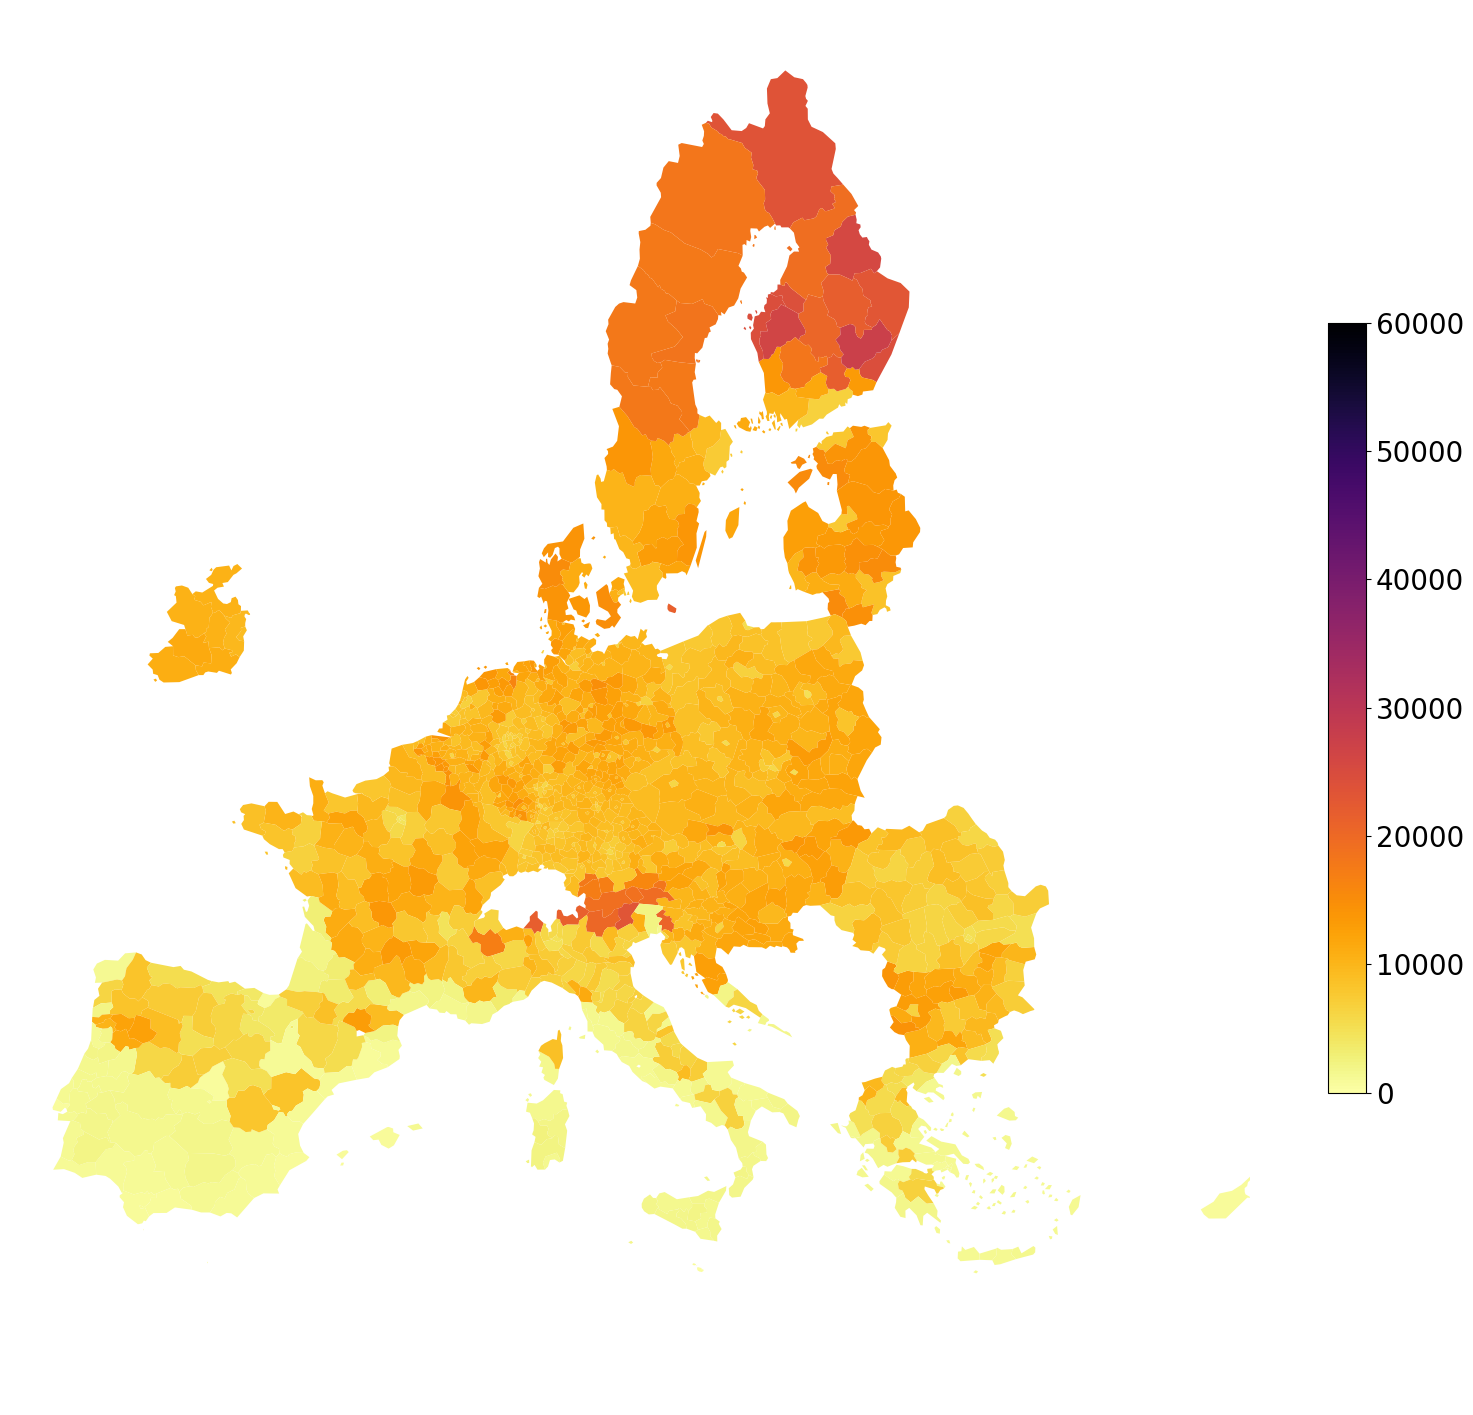

In [12]:
year = 2050
gdf = gpd.GeoDataFrame(ene_gdf[ene_gdf['year']==year])
#gdf = gpd.GeoDataFrame(ene_gdf)
col = 'heat_TJ'
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='inferno_r', #inferno_r
              #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
              norm=colors.Normalize(vmin=0, vmax=60000), 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
plt.savefig('plots/map_'+col+'_'+str(year)+'.png', bbox_inches='tight')

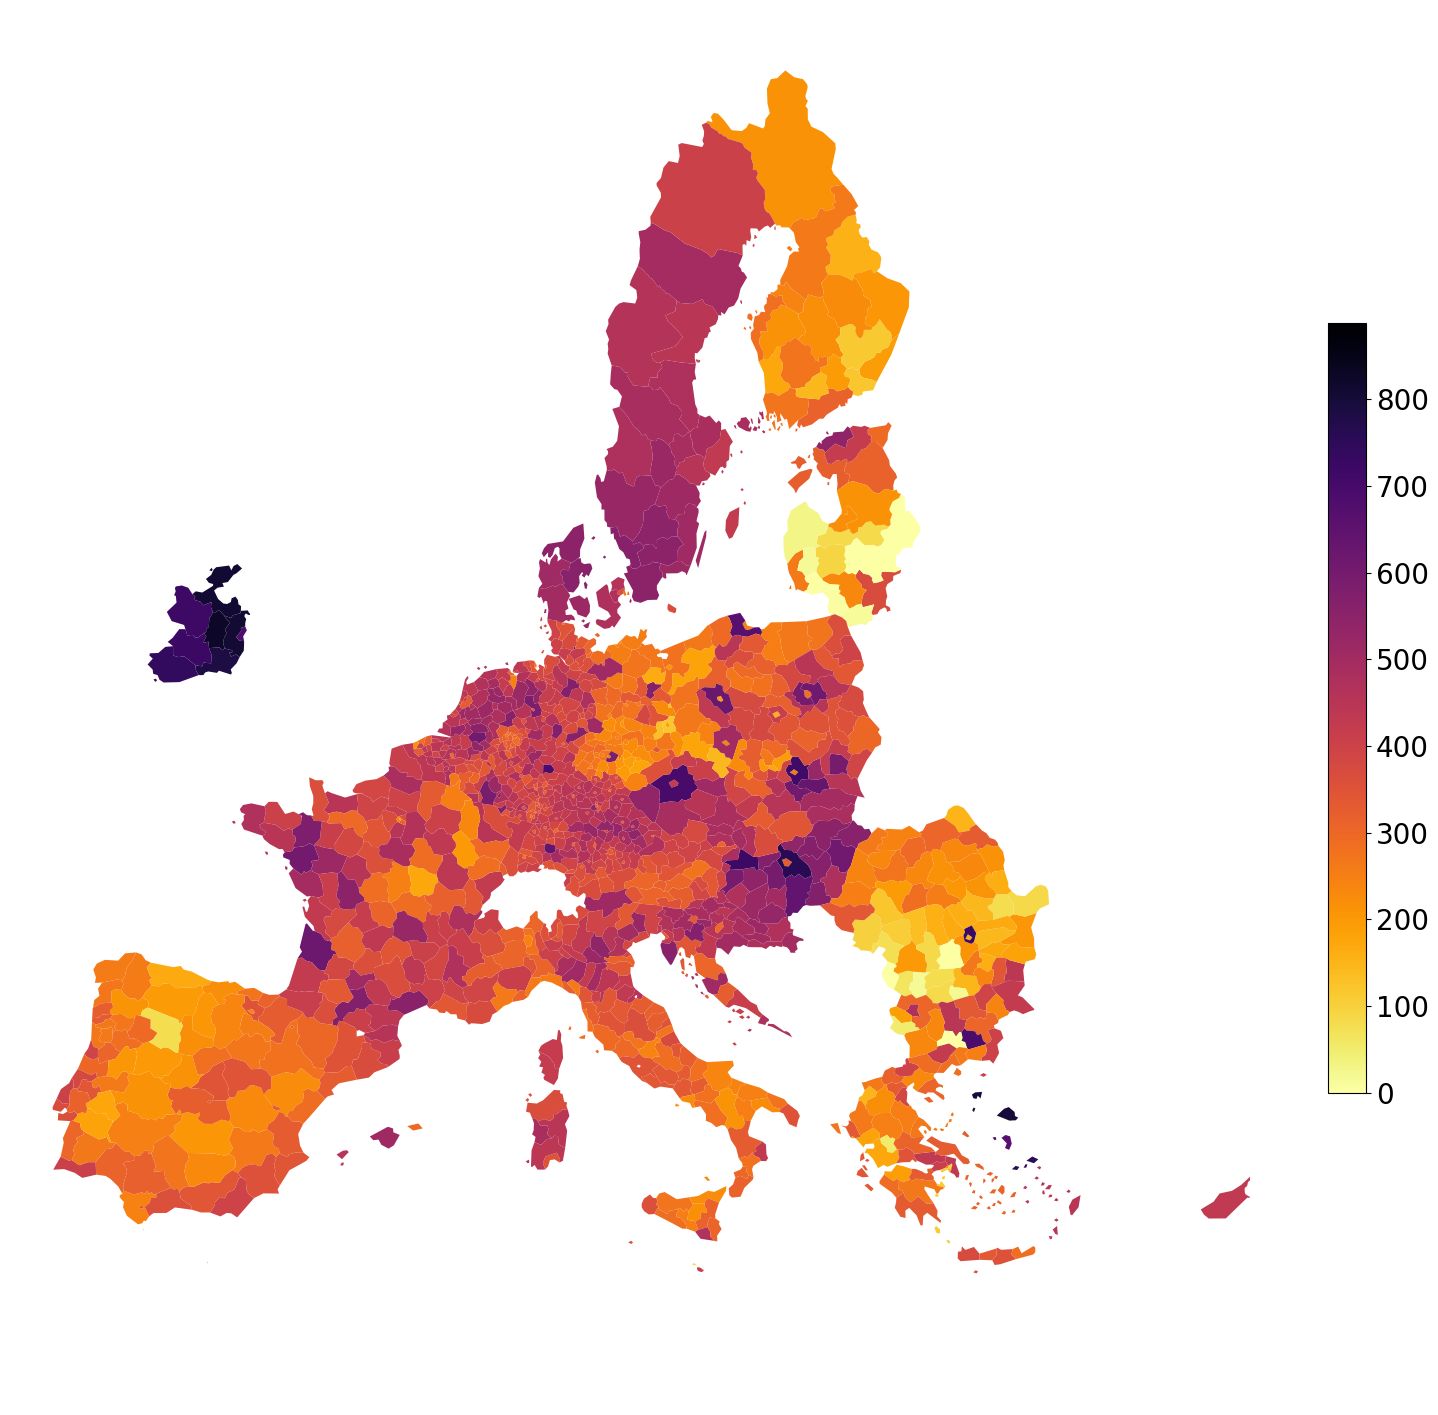

In [19]:
year = 2040
gdf = gpd.GeoDataFrame(mat_gdf[mat_gdf['year']==year])
#gdf = gpd.GeoDataFrame(ene_gdf)
col = 'mat_demand_Mt'
ax = gdf.plot(column=col, figsize=(20,20), legend=True, 
              #cmap='RdBu_r', 
              cmap='inferno_r', #inferno_r
              #norm=colors.LogNorm(vmin=gdf[col].min(), vmax=gdf[col].max()),
              #norm=colors.Normalize(vmin=0, vmax=1.5), 
              edgecolor=None,
              missing_kwds={'color': 'lightgrey'},
              legend_kwds={"shrink":.5},)
ax.figure.axes[1].tick_params(labelsize=20)
ax.set_xlim(0.25e7, 0.65e7)
ax.set_ylim(1e6, 5.5e6)
ax.set_axis_off()
plt.savefig('plots/map_'+col+'_'+str(year)+'.png', bbox_inches='tight')

## Components of material demand 
- floor area, material intensity & population trend
- (scatterplots with material demand) -to what extend do each of the components correlate with material demand (and are mechanically linked via the model)
